# 11 · Ad exposure is self-selected — the true effect (instrumental variables · CausalPy)

> **Runs in the `legacy` environment (pymc<6): `make env-legacy`, kernel `cmp-legacy`.**

**The business decision.** People who see our ads convert more — but the customers who *end up* seeing our
ads are also the ones already leaning toward us (they browse, they search, they get retargeted). So
**exposure is self-selected**, and a plain regression of sales on exposure is biased **upward**: it credits
the ad for enthusiasm that was already there. We want the *true* causal effect of an extra exposure so we
can set the right **budget** — the most we can pay per exposure and still come out ahead.

### The problem in one word: endogeneity

When the treatment (ad exposure) is **correlated with the hidden drivers of the outcome** (a customer's
unobserved intent), we say exposure is **endogenous**, and no amount of controlling for what we *measured*
fixes it — the confounder (intent) is unmeasured. Notebook 05's adjustment tools are powerless here.

### The fix: an instrument

An **instrumental variable (IV)** is a third variable $Z$ that nudges the treatment *without* affecting the
outcome any other way. Here $Z$ is a randomized **encouragement** — e.g. a serving-priority lottery that
makes some customers *more likely* to be shown the ad. Because $Z$ is randomized, the slice of exposure it
drives is as-good-as-random, uncontaminated by intent. IV isolates that clean slice and reads the effect
off it. A valid instrument needs **four** things:

- **Relevance** — $Z$ actually moves exposure (this one we *can* test: the **first-stage F-statistic**; F <
  10 is a "weak instrument" danger sign).
- **Exclusion** — $Z$ affects sales *only through* exposure (the lottery itself sells nothing). Untestable
  from data — defended on design, and stress-tested in Step 6.
- **Exogeneity** — $Z$ is independent of the hidden confounder (guaranteed here by randomization).
- **Monotonicity** — the encouragement never pushes anyone *away* from exposure (no "defiers": nobody is so
  annoyed by the nudge that they block ads in response). Untestable, but usually plausible for a gentle
  encouragement — and it is what buys the LATE interpretation below (derived in Step 3).

### What IV recovers: a LATE

IV does **not** give the average effect over everyone. It gives the **LATE** (*Local Average Treatment
Effect*) — the effect *for the "compliers,"* the customers whose exposure the encouragement actually
changed. Always-exposed loyalists and never-exposed sceptics are silent in an IV estimate; report the scope
accordingly.

> **On real data.** IV needs a genuine instrument, which is the hard part. Good marketing instruments:
> randomized **encouragement / intent-to-treat** designs (ship the nudge to a random half), ad-auction
> or delivery randomness, or a **cost shifter** for the price-elasticity problem in notebook 03. If you can
> randomize the *encouragement* (not the exposure itself), you have a clean instrument. Notebook **11b**
> (`11b_endogenous_exposure_real_data.ipynb`) runs this exact playbook on the real Criteo uplift data, where
> the randomized assignment instruments actual ad exposure — the real-world leg of this encouragement design.


In [1]:
import os, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
import causalpy as cp
from cmp import dgp, estimators as est, plots
from cmp.cache import load_or_run   # fit once, load forever — a live lecture never waits on NUTS
plots.use_style()
FAST = os.environ.get("CMP_FAST", "1") == "1"
SEED = 37; TRUE = 15.0

## 2 · Simulate a ground truth

The **true** exposure→sales effect is **€15**. An unobserved `engagement` drives both exposure and
sales (the confounding), so naive OLS overstates it. A randomized `encouragement` (the instrument)
nudges exposure without touching sales directly.

**The data-generating model** — exactly what `dgp.iv_ad_exposure` implements (defaults & seed in
`src/cmp/dgp.py`). $n = 3000$; **unobserved** intent $U = \text{engagement} \sim \mathcal N(0,1)$;
randomized encouragement $Z \sim \text{Bernoulli}(\tfrac12)$; $\sigma(z) = 1/(1+e^{-z})$:

$$
\begin{aligned}
X = \text{exposure} &\sim \text{Bernoulli}\big(\sigma(0.3 + 1.1\,Z + 0.8\,U)\big)
  &&\text{(first stage)}\\[2pt]
Y = \text{sales} &= 50 + 15\,X + 12\,U + \varepsilon,
  \qquad \varepsilon \sim \mathcal N(0,\, 6^{2}) &&\text{(true effect: the 15)}.
\end{aligned}
$$

$U$ appears in **both** equations — $0.8\,U$ pushes exposure and $12\,U$ pushes sales — that is the
self-selection, and since $U$ is unobserved no regression adjustment can fix it (OLS is biased
upward). All **four** IV conditions are visible by construction: **relevance** ($1.1 \ne 0$ — testable,
the first-stage F below), **exclusion** ($Z$ appears nowhere in the sales equation — untestable in
real data, stress-tested in step 6), **exogeneity** ($Z$ is a fair coin flip, drawn independently of
$U$ — randomization), and **monotonicity** ($1.1\,Z$ only ever *raises* the exposure probability — no
defiers).


In [2]:
df, true_effect = dgp.iv_ad_exposure(n=3000, true_effect=TRUE, seed=SEED)
Fstat = est.first_stage_F(df["encouragement"], df["ad_exposure"])
fs = df.groupby("encouragement")["ad_exposure"].mean()
print(f"TRUE exposure→sales effect €{true_effect:.0f}  ·  first-stage: exposure {fs[0]:.0%}→{fs[1]:.0%} "
      f"(shift {(fs[1]-fs[0])*100:+.0f} pp), F = {Fstat:.0f}")
df.head()

TRUE exposure→sales effect €15  ·  first-stage: exposure 56%→77% (shift +21 pp), F = 156


,encouragement,ad_exposure,sales
0,1.0,0.0,63.748992
1,1.0,1.0,64.636639
2,1.0,1.0,46.507627
3,0.0,1.0,75.599770
4,0.0,1.0,70.577754


## 3 · Identify — a valid instrument, and what IV recovers

Exposure is **endogenous** — it is correlated with the outcome's hidden driver, $\text{Cov}(\text{exposure},\,12U+\varepsilon)\neq 0$ (the $U$ term specifically, since $\varepsilon$ is independent structural noise) — so OLS is biased. The four
requirements from the intro, now each named, formalized, and argued in marketing terms:

- **Relevance** — $\pi \ne 0$ in the first stage $X = b_0 + \pi Z + u$: the encouragement genuinely moves
  exposure. *Testable* — and the only assumption the data can check. The first-stage F is printed in §2;
  **Step 0** below defines it, derives the F < 10 rule of thumb, and prices what a strong
  instrument leaks, and §5c degrades the instrument until the estimator comes apart.
- **Exclusion** — the encouragement has **no arrow of its own into sales**. In potential-outcomes notation,
  writing $Y_i(z,x)$ for customer $i$'s sales if we *set* encouragement to $z$ and exposure to $x$:

$$
Y_i(z, x) \;=\; Y_i(x) \qquad \text{for all } z \in \{0,1\}:
$$

  holding exposure fixed, flipping the lottery changes nothing. *Untestable from data* — defended on design
  (a serving-priority lottery sells nothing by itself; an encouragement *email that shows the product*
  would violate it), and stress-tested in Step 6.
- **Exogeneity / independence** — $Z \perp (U, \varepsilon)$: the instrument is unrelated to the hidden
  drivers of exposure and sales. Holds here **by randomization** of the lottery.
- **Monotonicity** — $X_i(1) \ge X_i(0)$ for every customer $i$, where $X_i(z)$ is $i$'s exposure when the
  encouragement is set to $z$: the nudge never pushes anyone *away* from the ad (no defiers). *Untestable*;
  plausible for a gentle encouragement, and it is precisely what turns the IV ratio into an interpretable
  LATE — the derivation below uses it to kill one term.

The DAG states the structural part in one picture — and teaches that two of the assumptions are
**missing arrows**:

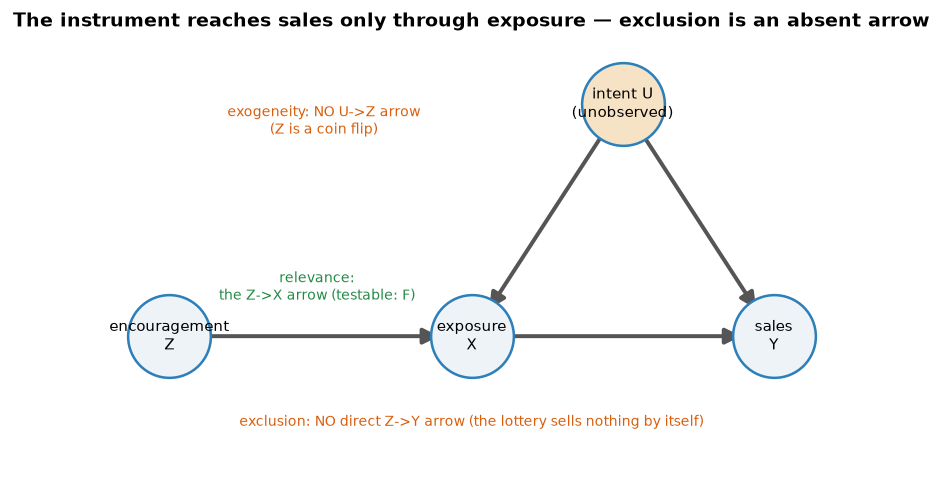

In [3]:
fig, ax = plt.subplots(figsize=(7.0, 3.8))
pos = {"encouragement\nZ": (0.05, 0.25), "exposure\nX": (0.5, 0.25),
       "sales\nY": (0.95, 0.25), "intent U\n(unobserved)": (0.725, 0.95)}
edges = [("encouragement\nZ", "exposure\nX"), ("exposure\nX", "sales\nY"),
         ("intent U\n(unobserved)", "exposure\nX"), ("intent U\n(unobserved)", "sales\nY")]
plots.draw_dag(ax, pos, edges, node_colors={"intent U\n(unobserved)": "#f6e3c5"},
               title="The instrument reaches sales only through exposure — exclusion is an absent arrow")
ax.text(0.27, 0.36, "relevance:\nthe Z->X arrow (testable: F)", ha="center", fontsize=8, color=plots.GREEN)
ax.text(0.50, -0.02, "exclusion: NO direct Z->Y arrow (the lottery sells nothing by itself)",
        ha="center", fontsize=8, color=plots.ORANGE)
ax.text(0.28, 0.86, "exogeneity: NO U->Z arrow\n(Z is a coin flip)", ha="center", fontsize=8, color=plots.ORANGE)
fig.tight_layout()

**Read the DAG by its absences.** The unobserved intent $U$ points into both exposure and sales — that
fork is the endogeneity OLS trips over, and no arrow into $U$ can be measured away. The instrument $Z$
has exactly **one** outgoing arrow, into exposure: exclusion and exogeneity are not things $Z$ *does*,
they are arrows $Z$ *does not have* — which is why they cannot be tested from data, only designed for.
Relevance is the one arrow $Z$ must have, and the only assumption the data can check.

**Who is in the estimate? The four customer types.** With $X_i(z) \in \{0,1\}$ the exposure customer $i$
would end up with under encouragement $z$, two potential exposures give four types — the IV analogue of
notebook 01's Persuadable / Sleeping-Dog grid:

| | $X_i(1)=1$ — exposed if encouraged | $X_i(1)=0$ — unexposed if encouraged |
|---|---|---|
| **$X_i(0)=1$** — exposed anyway | **Always-taker** — brand loyalist who seeks the ad out regardless; the lottery changes nothing | **Defier** — so annoyed by the nudge they block the ad they'd otherwise have seen. *Ruled out by monotonicity* |
| **$X_i(0)=0$** — unexposed otherwise | **Complier** — the lottery tips them into seeing the ad. *The only type IV speaks for* | **Never-taker** — ad-blocker user, barely online; unreachable either way |

**The LATE theorem (Imbens–Angrist), in two lines.** Decompose the **ITT** (intent-to-treat) effect on
sales — the average sales difference between encouraged and not-encouraged customers, which *is* the reduced
form — over the four types. Randomization of $Z$ makes encouraged vs not comparable; **exclusion** says sales can
only react to $Z$ if exposure changed, which silences always- and never-takers ($X_i(1) = X_i(0)$);
**monotonicity** deletes the defier term. What survives is the compliers:

$$
\underbrace{E[Y\mid Z{=}1]-E[Y\mid Z{=}0]}_{\text{ITT on sales (reduced form)}}
\;=\; E\big[\big(Y_i(1)-Y_i(0)\big)\big(X_i(1)-X_i(0)\big)\big]
\;=\; \Pr(\text{complier})\cdot \underbrace{E\big[Y_i(1)-Y_i(0)\mid \text{complier}\big]}_{\text{LATE}}.
$$

The same decomposition applied to exposure itself gives
$E[X\mid Z{=}1]-E[X\mid Z{=}0] = \Pr(\text{complier})$ — **the first stage *is* the complier share** (the
+21 pp printed in Step 2: about a fifth of these customers are compliers). Divide the two:

$$
\text{LATE} \;=\; \frac{E[Y\mid Z{=}1]-E[Y\mid Z{=}0]}{E[X\mid Z{=}1]-E[X\mid Z{=}0]}
\;=\; \frac{\text{reduced form}}{\text{first stage}} \;=\; \hat\beta_{\text{Wald}}.
$$

So IV does **not** estimate the average effect over everyone: always-takers and never-takers cancel out
of the numerator and are literally absent from the estimate — the LATE is the effect *for the customers
the encouragement can move*. CausalPy fits the Bayesian version of this ratio: a joint model of
(exposure, sales) with correlated errors, *estimating* the endogeneity $\rho$ rather than assuming it away.

> **Modeling note.** Because `ad_exposure` is binary (0/1), this joint MvNormal models the exposure first stage as a **linear-probability (Gaussian)** equation, so the two-equation model is an approximation. §4b makes that misfit visible on purpose (32% of the "exposures" it replicates are impossible values), §5b prices what it costs (+€1.5 of bias, 80% coverage on a nominal-90% interval), and **§5z repairs it** — a **probit** first stage, a latent index crossing a threshold, which is where a binary treatment actually comes from. The effect posterior this notebook ships to §6 is §5z's (€16.5); §4's Gaussian fit (€17.7) is kept alongside it for the comparison.

## Step 0 · The classical read (no likelihood, no priors, no sampler)

Before any Bayesian machinery, ask what a competent analyst would do here **without** it. The answer is
not a different analysis: it is the *same estimand* (the complier LATE of §3), identified by the *same
four assumptions* (relevance, exclusion, exogeneity, monotonicity), estimated with the simplest tool that
is still correct. The causal work lives in the identification argument, not in the machinery — and IV's
machinery is old enough (Wright, 1928) that it predates the computer, let alone the sampler.

**Three regressions, and the reader must see all three naked, in this order:**

$$
\underbrace{Y = a_0 + a_1 X}_{\textbf{(1) naive OLS — BIASED}}, \qquad
\underbrace{X = b_0 + \pi Z}_{\textbf{(2) first stage}}, \qquad
\underbrace{Y = c_0 + \delta Z}_{\textbf{(3) reduced form}} .
$$

Regression (1) is the number the business would have used, and §2's data-generating model already told us
it is wrong. Regressions (2) and (3) each regress on the **randomized** lottery $Z$, so each is a clean
experiment — but neither is the answer: the first stage is measured in *exposures*, the reduced form in
*euros of sales*. Divide one by the other and the units cancel into euros **per exposure**. That is the
**Wald ratio**, and it is the whole of IV:

$$
\hat\beta_{\text{IV}} \;=\; \frac{\hat\delta}{\hat\pi}
\;=\; \frac{\widehat{\text{Cov}}(Y, Z)}{\widehat{\text{Cov}}(X, Z)}
\;=\; \frac{\bar{Y}_{Z=1} - \bar{Y}_{Z=0}}{\bar{X}_{Z=1} - \bar{X}_{Z=0}}
\;=\; \frac{\text{ITT — what the lottery did to sales}}{\text{compliance — what it did to exposure}} .
$$

The lottery moved sales by $\hat\delta$ and exposure by $\hat\pi$; each unit of *lottery-driven* exposure
is therefore worth their ratio, and §3's LATE theorem is the argument that this ratio is a causal effect
(for compliers). **With a single binary instrument and no controls, two-stage least squares is exactly
this ratio** — `cl.iv_2sls` and $\hat\delta/\hat\pi$ agree to floating point, and the cell below *asserts*
that rather than asking you to take it on faith. So why run 2SLS at all? For the two things a bare ratio
cannot carry: a **standard error** and the **first-stage F**.

**Predict the OLS bias before running the regression.** Because we built the DGM, we can compute exactly
how wrong regression (1) will be — before it is wrong. With $Y = 50 + 15X + 12U + \varepsilon$, the OLS
slope of $Y$ on $X$ converges to the planted effect **plus** whatever part of the error leaks in through
the treatment (the **omitted-variable-bias** formula, specialized to this DGM):

$$
\hat a_1 \;\xrightarrow{\;p\;}\; 15 \;+\; \frac{\text{Cov}(X,\; 12U+\varepsilon)}{\text{Var}(X)}
\;=\; 15 \;+\; 12\,\frac{\text{Cov}(X, U)}{\text{Var}(X)},
$$

since $\varepsilon$ is independent noise. Even the sign is knowable in advance: the first stage loads on
$U$ with $+0.8$, so $\text{Cov}(X,U) > 0$ and OLS must be biased **upward**. The code below re-draws the
same simulation *retaining the normally-unobservable* $U$, evaluates this formula, and only then runs the
regressions — theory should call the OLS number before the regression prints it. (That same
$\text{Cov}(X,U)$ has a second life in §4, where the Bayesian joint model estimates it as a positive error
correlation $\rho$.)

**The covariance choice, and its one-line reason.** This is a cross-section of 3,000 customers — no panel,
no time series, so no clustering and no HAC. But exposure is **binary**, and by construction the sales
variance differs between the exposed and the unexposed arms: the errors are heteroskedastic *by design*.
So all three regressions above take **HC1** (heteroskedasticity-robust) standard errors — the right formula
for a cross-section that is not homoskedastic. The IV estimate needs more care still. If you hand-roll the
second stage — regress $Y$ on the **fitted** $\hat X$ from stage one and read `statsmodels`' standard error
off that fit — you get a number that is simply *not* the 2SLS standard error, because the residuals are
formed against $\hat X$ instead of the real $X$. `cl.iv_2sls` uses the correct residuals. The cell prints
both, and (as in notebook 08) the direction of the error is not the one folklore predicts.

**Relevance, measured: the first-stage F and the F < 10 rule — invented here, in the classical arm.** For
a single instrument, the first-stage F is the ordinary F-statistic of regression (2):

$$
F \;=\; \frac{R^2 / 1}{\,(1-R^2)/(n-2)\,},
$$

where $R^2$ is the share of exposure variance the instrument explains and $n-2$ counts the residual degrees
of freedom: F measures the instrument's **signal in the first stage relative to noise**. **Why is the
folklore threshold 10?** With one instrument, a standard approximation says the 2SLS estimator's residual
bias, *relative to the OLS bias it is supposed to remove*, is roughly the reciprocal of F:

$$
\frac{E[\hat\beta_{\text{2SLS}}] - \beta}{E[\hat\beta_{\text{OLS}}] - \beta} \;\approx\; \frac{1}{F},
$$

so F = 10 means "no more than about a tenth of the OLS bias leaks back in" — a rule with teeth, not
folklore. The cell cashes that formula out in euros on *this* instrument. `cl.iv_2sls` returns the F and a
`weak` flag (F < 10) precisely so that the check cannot be skipped; **§5c runs the rule backwards** —
degrading the instrument on purpose until F falls through 10 — and watches the estimator come apart.
(Caveat, from `first_stage_F`'s own docstring: this is the classical **homoskedastic** F. On real,
heteroskedastic data prefer the Montiel Olea–Pflueger **effective F**, which corrects the threshold for
non-constant first-stage noise, and treat F > 10 as necessary, not sufficient.)


In [4]:
from cmp import classical as cl
import statsmodels.api as sm

# --- Theory first: predict the OLS bias BEFORE the regression runs --------------------
# Re-draw the identical simulation (same seed, same call order as dgp.iv_ad_exposure)
# keeping the normally-unobservable U, and evaluate 15 + 12*Cov(X,U)/Var(X).
_rng = np.random.default_rng(SEED)
_U = _rng.normal(0, 1, len(df)); _Z = _rng.integers(0, 2, len(df)).astype(float)
_X = (_rng.uniform(size=len(df)) < 1.0 / (1.0 + np.exp(-(0.3 + 1.1 * _Z + 0.8 * _U)))).astype(float)
assert np.allclose(_X, df["ad_exposure"])   # identical draw — this IS the notebook's exposure column
ovb = 12 * np.cov(_X, _U)[0, 1] / _X.var()
print("OVB theory, computed BEFORE any regression is run:")
print(f"  OLS ->p 15 + 12*Cov(X,U)/Var(X) = 15 + {ovb:.1f} = €{15 + ovb:.1f}\n")

# --- The three regressions, naked. HC1: binary exposure => heteroskedastic by construction.
ols_naive = cl.ols(df, "sales ~ ad_exposure", target="ad_exposure", cov="HC1",
                   name="(1) naive OLS    Y~X  [BIASED]")
first_st = cl.ols(df, "ad_exposure ~ encouragement", target="encouragement", cov="HC1",
                  name="(2) first stage  X~Z  (pi)")
red_form = cl.ols(df, "sales ~ encouragement", target="encouragement", cov="HC1",
                  name="(3) reduced form Y~Z  (delta)")
for _r in (ols_naive, first_st, red_form):
    print(_r)
naive, first, reduced = ols_naive.estimate, first_st.estimate, red_form.estimate

# --- (4) 2SLS: the Wald ratio, plus the SE and the F that a bare ratio cannot carry ----
iv2 = cl.iv_2sls(df, outcome="sales", endog="ad_exposure", instrument="encouragement")
wald = reduced / first
print(f"\n{iv2}")
print(f"THE WALD IDENTITY   delta/pi = {reduced:.4f} / {first:.4f} = €{wald:.4f}"
      f"   vs   2SLS = €{iv2.estimate:.4f}")
assert abs(wald - iv2.estimate) < 1e-8   # one binary instrument, no controls: the SAME estimator
print("  -> identical to floating point. 2SLS *is* the Wald ratio here; the machinery buys the SE and the F.")

# --- The standard error: the one you must NOT use, the right one, and a robustness check
Zr = np.column_stack([np.ones(len(df)), df["encouragement"].values])        # [1, Z] design
_xhat = Zr @ np.linalg.lstsq(Zr, df["ad_exposure"].values, rcond=None)[0]   # fitted first stage
_se_naive2nd = float(sm.OLS(df["sales"].values,
                            np.column_stack([np.ones(len(df)), _xhat])).fit().bse[1])
# HC1 sandwich for 2SLS: V = (Xhat'X)^-1 [sum e_i^2 xhat_i xhat_i'] (Xhat'X)^-1, e = y - X b_2sls
_Xm = np.column_stack([np.ones(len(df)), df["ad_exposure"].values])
_Xh = np.column_stack([np.ones(len(df)), _xhat])
_A = np.linalg.inv(_Xh.T @ _Xm)
_e2s = df["sales"].values - _Xm @ (_A @ (_Xh.T @ df["sales"].values))
_n, _k = _Xm.shape
_V = _A @ (_Xh.T @ (_Xh * (_e2s ** 2)[:, None])) @ _A.T * (_n / (_n - _k))
se_hc1 = float(np.sqrt(_V[1, 1]))
print(f"\nSTANDARD ERROR — three formulas for the SAME €{iv2.estimate:.1f} point estimate:")
print(f"  hand-rolled 2nd-stage OLS (residuals vs the FITTED Xhat — WRONG) : {_se_naive2nd:5.2f}")
print(f"  proper 2SLS               (residuals vs the REAL X)              : {iv2.se:5.2f}  <- cl.iv_2sls")
print(f"  2SLS + HC1 sandwich       (heteroskedasticity-robust)            : {se_hc1:5.2f}")
print(f"  -> the hand-rolled SE is x{_se_naive2nd / iv2.se:.2f} the correct one — and note the DIRECTION: too")
print(f"     WIDE, not too narrow. Its residual y - b*Xhat carries an extra beta^2*Var(X - Xhat) term")
print(f"     (a non-negative quantity), so it charges the estimate for first-stage scatter that is not")
print(f"     sampling error at all. Robustness, by contrast, barely moves it (x{se_hc1 / iv2.se:.2f}): the")
print(f"     homoskedastic 2SLS interval printed above is safe to report as-is.")

# --- Relevance: the F, the weak flag, and the 1/F rule cashed out in euros -------------
_F = iv2.extra["first_stage_F"]
print(f"\nRELEVANCE — first-stage F = {_F:.0f}   (cl.iv_2sls weak flag: "
      f"{'WEAK — do not report this ratio' if iv2.extra['weak'] else 'strong, F >> 10'})")
print(f"  1/F cashed out: OLS is off by €{naive - true_effect:+.1f}; the rule says ~1/F of that bias")
print(f"  leaks back into 2SLS -> €{abs(naive - true_effect):.1f} / {_F:.0f} ≈ €{abs(naive - true_effect) / _F:.2f} per "
      f"exposure. Negligible — which is why §5b's")
print("  residual bias (an order of magnitude larger) cannot be blamed on the instrument.")

# --- Grade against the planted truth --------------------------------------------------
_in_iv = iv2.ci[0] <= true_effect <= iv2.ci[1]
_in_ols = ols_naive.ci[0] <= true_effect <= ols_naive.ci[1]
print(f"\nGRADE vs the planted truth (€{true_effect:.0f}/exposure):")
print(f"  (1) naive OLS  €{naive:5.1f}  off by €{naive - true_effect:+.1f}   truth is "
      f"{'INSIDE' if _in_ols else 'OUTSIDE'} its 90% CI [€{ols_naive.ci[0]:.1f}, €{ols_naive.ci[1]:.1f}]")
print(f"      — the tightest interval in the notebook (SE €{ols_naive.se:.2f}) around a number that is "
      f"€{naive - true_effect:.1f} wrong.")
print(f"        Precision is not accuracy: a confident interval on a biased estimator is a confident lie.")
print(f"  (4) 2SLS       €{iv2.estimate:5.1f}  off by €{iv2.estimate - true_effect:+.1f}   truth is "
      f"{'INSIDE' if _in_iv else 'OUTSIDE'} its 90% CI [€{iv2.ci[0]:.1f}, €{iv2.ci[1]:.1f}]")
print(f"      — the self-selection wedge the instrument removed: €{naive - iv2.estimate:.1f} per exposure.")
print("\n" + iv2.cannot_say())


OVB theory, computed BEFORE any regression is run:
  OLS ->p 15 + 12*Cov(X,U)/Var(X) = 15 + 8.5 = €23.5

(1) naive OLS    Y~X  [BIASED]: 23.67  [90% CI 22.86, 24.48]  (SE 0.492, HC1 heteroskedasticity-robust, n=3,000)
(2) first stage  X~Z  (pi): 0.2106  [90% CI 0.1828, 0.2383]  (SE 0.0169, HC1 heteroskedasticity-robust, n=3,000)
(3) reduced form Y~Z  (delta): 3.484  [90% CI 2.463, 4.506]  (SE 0.621, HC1 heteroskedasticity-robust, n=3,000)

LATE (2SLS): 16.55  [90% CI 12.74, 20.35]  (SE 2.31, 2SLS (homoskedastic), n=3,000)
THE WALD IDENTITY   delta/pi = 3.4844 / 0.2106 = €16.5470   vs   2SLS = €16.5470
  -> identical to floating point. 2SLS *is* the Wald ratio here; the machinery buys the SE and the F.

STANDARD ERROR — three formulas for the SAME €16.5 point estimate:
  hand-rolled 2nd-stage OLS (residuals vs the FITTED Xhat — WRONG) :  2.95
  proper 2SLS               (residuals vs the REAL X)              :  2.31  <- cl.iv_2sls
  2SLS + HC1 sandwich       (heteroskedasticity-robust) 

**Read-out — the classical answer, in business terms.** The naive regression prices an exposure at the
number printed above; 2SLS prices it several euros lower, and the difference between them *is* the
self-selection — euros of "effect" that were never caused by the ad, only correlated with the enthusiasm
of the people who ended up seeing it. Budget on the first number and you overpay on every exposure bought;
§6 turns the second into a bid cap. Three details are worth pausing on, because each is a lesson the
Bayesian section will inherit rather than replace:

1. **The theory called the OLS number before the regression ran.** The omitted-variable-bias prediction
   and the fitted OLS slope (both printed above) agree to a fraction of a euro. The bias is
   not bad luck or a small sample — it is a *computable* consequence of the DGM, and on real data the same
   formula tells you the *sign* of your bias even when you cannot compute its size.
2. **The naive OLS interval is the tightest in this notebook and it misses the truth entirely.** It is off
   by more than half the effect, with a standard error small enough to look authoritative. This is the
   single most useful thing in Step 0: **precision is not accuracy**, and no amount of extra data would
   have saved it — more customers would only shrink that interval around the same wrong number.
3. **The first-stage F is a precondition, not a footnote.** F in the hundreds is what entitles us to read
   the ratio at all; the 1/F cash-out prices the residual leakage at a few cents. §5c shows what the same
   estimator does when that number falls below 10 — it is not a graceful degradation.

Notice what has *not* happened yet. No likelihood was written down, no prior was chosen, no sampler ran.
The identification — a randomized instrument, excluded and monotone — did all the causal work, and two
least-squares slopes and a division did all the estimation. **This is the honest baseline against which
the Bayesian section must justify itself**, and §5x will hold it to that.

**The guardrail — what that confidence interval does *not* say** (printed above by `cannot_say()`, in the
same words in every notebook of this cookbook): it is **not** a 90% probability that the true
exposure→sales effect lies inside it. A confidence interval is a property of the *procedure* — 90% of
intervals built this way would cover the truth across repeated samples — and this particular interval
either covers the truth or it does not. Here is exactly where that bites: §6 must answer *"what is the
probability an exposure is worth more than the €15 we would have to bid for it?"* That sentence asks for a
probability **about the effect itself**. The classical apparatus cannot supply one — not because its
arithmetic is worse (it is not — with a correctly specified likelihood the two land on top of each other:
2SLS €16.5 against the shipped posterior's €16.5, a tie §5x reads out in full), but because that
quantity does not exist in its vocabulary. It exists in a posterior. That, and not a better point
estimate, is what the next section is for.


## 4 · Estimate — the Bayesian IV model

Step 0 already produced a causal number: the Wald ratio, which is 2SLS, with an honest confidence
interval and a first-stage F that certifies the instrument. What follows does **not** change the
identification by a comma — same instrument, same four assumptions, same complier LATE. It changes the
apparatus for expressing uncertainty about that number, and it estimates one object the classical route
structurally cannot hand you: the **endogeneity itself**.

The Bayesian IV fits the first stage and the outcome equation **jointly**, allowing their errors to be
correlated:

$$
\begin{pmatrix} X_i \\ Y_i \end{pmatrix} \sim
\mathcal N_2\!\left( \begin{pmatrix} b_0 + \pi Z_i \\ \beta_0 + \beta X_i \end{pmatrix},\;
\Sigma \right), \qquad
\Sigma = \begin{pmatrix} \sigma_X^{2} & \rho\,\sigma_X \sigma_Y \\
  \rho\,\sigma_X \sigma_Y & \sigma_Y^{2} \end{pmatrix},
$$

where the off-diagonal $\rho$ **is** the endogeneity: the correlation between the two equations' errors
that the hidden $U$ induces and that OLS ignores. Priors: weakly-informative $\mathcal N(0, 50^{2})$ on
the regression coefficients (the code comment explains why the library default is too tight here) and an
**LKJ prior** on $\Sigma$ — a standard weakly-informative prior over correlation matrices that lets the
data decide how strongly the two equations' errors move together (i.e. how big $\rho$ is), rather than
fixing it in advance. The $\beta$ in the second row is the same $\beta$ Step 0 estimated by 2SLS: one
estimand, two machines.

**The one genuinely new object: $\rho$.** 2SLS *removes* the endogeneity by projection — it never names
it, and it has no $\rho$ to report. The joint model *estimates* it, and the posterior for $\rho$ turns
out to be the Bayesian image of exactly the $\text{Cov}(X, U)$ that Step 0's omitted-variable-bias
formula priced in euros. A positive $\rho$ **is** the reason the OLS number sat above the IV number; here
we get an interval on it. That, plus the ability to ask $P(\beta > \text{cost})$ in §6, is what the
sampler is being paid for — and §5x audits whether it earned its fee.

**One thing to flag before the fit.** The $X$ row of that MvNormal is a **Gaussian** equation for a **0/1**
treatment — a linear probability model in disguise. §4b makes the damage visible, §5b measures it, and
**§5z rewrites that row as a probit**. From §5z on, `iv_post` — the posterior §5x, §6 and the book export
all consume — is the **probit** posterior (€16.5, 90% [€12.9, €20.1]); the Gaussian fit below (€17.7, 90%
[€14.3, €21.1]) is preserved as `iv_post_gauss` for the side-by-side. Read this section as the standard
model, flaws included — not as the notebook's final number.


In [5]:
# The classical quantities (naive, reduced, first, wald, iv2) were computed in Step 0 and are
# reused here; this cell adds ONLY the Bayesian machinery.
# Bayesian IV — pass WEAKLY-INFORMATIVE priors. CausalPy 0.8.1 otherwise centres the
# beta priors on the 2SLS point with sigma=1, far too tight. We do not assert what that
# costs — the PRIORS, PRICED block below FITS the default and prints its band.
iv_idata = load_or_run(
    "11_iv_gaussian",
    lambda: est.iv(df, "ad_exposure ~ 1 + encouragement", "sales ~ 1 + ad_exposure",
                   instrument_col="encouragement", treatment_col="ad_exposure", outcome_col="sales",
                   fast=FAST, priors={"mus": [0, 0], "sigmas": [50, 50], "eta": 2, "lkj_sd": 2}).idata,
    inputs=dict(seed=SEED, fast=FAST, model="causalpy-gaussian"))
iv_post = iv_idata.posterior["beta_z"].sel(covariates="ad_exposure").values.ravel()
print(f"Step 0, recalled:   OLS (biased) €{naive:.1f}   ·   Wald = 2SLS €{wald:.1f} "
      f"(90% CI [€{iv2.ci[0]:.1f}, €{iv2.ci[1]:.1f}])")
print(f"Bayesian IV         €{iv_post.mean():.1f}  (true €{true_effect:.0f})  "
      f"90% credible interval [€{np.quantile(iv_post,0.05):.1f}, €{np.quantile(iv_post,0.95):.1f}]")
print(f"IV convergence: {est.convergence_report(iv_idata)['summary']}")

# --- PRIORS, PRICED: fit the library DEFAULT once and print what it does ------------------
# The gotcha above, measured rather than asserted: same data, same sampler, only the priors
# differ. (Cheap: one extra fit on n=3,000.)
_res_def = est.iv(df, "ad_exposure ~ 1 + encouragement", "sales ~ 1 + ad_exposure",
                  instrument_col="encouragement", treatment_col="ad_exposure",
                  outcome_col="sales", fast=FAST, priors=None)          # priors=None -> library default
_post_def = _res_def.idata.posterior["beta_z"].sel(covariates="ad_exposure").values.ravel()
_dlo, _dhi = np.quantile(_post_def, [0.05, 0.95])
_wlo, _whi = np.quantile(iv_post, [0.05, 0.95])
_inside = lambda lo, hi: "INSIDE" if lo <= true_effect <= hi else "OUTSIDE — it MISSES the truth"
print(f"\nPRIORS, PRICED — the library default vs the weakly-informative override:")
print(f"  CausalPy 0.8.1 default    €{_post_def.mean():5.1f}  90% [€{_dlo:.1f}, €{_dhi:.1f}]  "
      f"width €{_dhi - _dlo:.1f}  -> true €{true_effect:.0f} is {_inside(_dlo, _dhi)}")
print(f"  N(0, 50^2) [used above]   €{iv_post.mean():5.1f}  90% [€{_wlo:.1f}, €{_whi:.1f}]  "
      f"width €{_whi - _wlo:.1f}  -> true €{true_effect:.0f} is {_inside(_wlo, _whi)}")
print(f"  the default band is {(_whi - _wlo) / (_dhi - _dlo):.1f}x TOO NARROW (the classical Wald 90% CI, "
      f"an independent yardstick, is €{iv2.ci[1] - iv2.ci[0]:.1f} wide).")
print(f"  A prior centred on the 2SLS point with sigma=1 does not let the data speak: it hard-codes")
print(f"  the answer and then reports false confidence in it. That is why sigmas=[50, 50] is passed.")

# Estimate of the endogeneity itself: the correlation rho between the exposure-equation
# and sales-equation error terms. IV *estimates* this rather than assuming it away — a
# nonzero rho is precisely why OLS is biased. CausalPy fits a 2x2 LKJ error covariance.
_post = iv_idata.posterior
_Sig, _rho = None, None   # per-draw 2x2 error covariance; ROW/COL ORDER (sales, exposure) — the
try:                      # model stacks (mu_y, mu_t). Reused by the posterior predictive check in 4b.
    if "cov" in _post:                        # this CausalPy version stores Sigma directly
        _Sig = np.asarray(_post["cov"].values).reshape(-1, 2, 2)
    elif "chol_cov" in _post:                 # otherwise rebuild it from the Cholesky factor
        _ch = np.asarray(_post["chol_cov"].values)
        _flat = _ch.reshape(-1, *_ch.shape[2:])   # collapse chain/draw
        def _Sigma_from(x):
            x = np.asarray(x)
            if x.shape == (2, 2):      # full lower-triangular L
                L = x
            elif x.size == 3:          # packed [L00, L10, L11]
                L = np.array([[x[0], 0.0], [x[1], x[2]]])
            else:
                return np.full((2, 2), np.nan)
            return L @ L.T
        _Sig = np.array([_Sigma_from(x) for x in _flat])
except Exception as _e:
    print(f"(could not extract the error covariance: {_e})")
if _Sig is not None:
    _ok = np.isfinite(_Sig).all(axis=(1, 2))
    _rho = _Sig[_ok, 0, 1] / np.sqrt(_Sig[_ok, 0, 0] * _Sig[_ok, 1, 1])
    print(f"\nEstimated endogeneity  rho(exposure err, sales err) = {_rho.mean():+.2f} "
          f"[90% {np.quantile(_rho, 0.05):+.2f}, {np.quantile(_rho, 0.95):+.2f}]\n"
          f"  — nonzero rho is why OLS (€{naive:.1f}) sits above IV (€{iv_post.mean():.1f}); it is the Bayesian\n"
          f"  image of the same Cov(X,U) Step 0's OVB formula priced at +€{ovb:.1f}. No classical\n"
          f"  estimator in Step 0 has a rho to report: 2SLS projects the bias away without naming it.")


[cache] loaded '11_iv_gaussian' (89s fit, cached 0.4h ago) — nothing re-sampled.
Step 0, recalled:   OLS (biased) €23.7   ·   Wald = 2SLS €16.5 (90% CI [€12.7, €20.4])
Bayesian IV         €17.7  (true €15)  90% credible interval [€14.3, €21.1]
IV convergence: max r-hat 1.010 - min ESS 903 - divergences 0


Initializing NUTS using jitter+adapt_diag...


Sequential sampling (4 chains in 1 job)


NUTS: [beta_t, beta_z, chol_cov]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 45 seconds.



PRIORS, PRICED — the library default vs the weakly-informative override:
  CausalPy 0.8.1 default    € 16.6  90% [€15.3, €17.9]  width €2.6  -> true €15 is OUTSIDE — it MISSES the truth
  N(0, 50^2) [used above]   € 17.7  90% [€14.3, €21.1]  width €6.8  -> true €15 is INSIDE
  the default band is 2.6x TOO NARROW (the classical Wald 90% CI, an independent yardstick, is €7.6 wide).
  A prior centred on the 2SLS point with sigma=1 does not let the data speak: it hard-codes
  the answer and then reports false confidence in it. That is why sigmas=[50, 50] is passed.

Estimated endogeneity  rho(exposure err, sales err) = +0.22 [90% +0.10, +0.33]
  — nonzero rho is why OLS (€23.7) sits above IV (€17.7); it is the Bayesian
  image of the same Cov(X,U) Step 0's OVB formula priced at +€8.5. No classical
  estimator in Step 0 has a rho to report: 2SLS projects the bias away without naming it.


**Reading the sampler's two health checks.** The Bayesian IV is fit by simulation — **MCMC**, the
algorithm that draws samples from the posterior — so PyMC prints two numbers that say whether the sampler
actually converged, and it will warn loudly if they look loose. **R-hat** compares the variance *within*
each MCMC chain to the variance *across* chains; it should sit at ≈1.00, and **≤ 1.01 is the usual pass
bar**. **ESS** (effective sample size) is roughly how many *independent* draws the autocorrelated chain is
worth — a few hundred is ample for a posterior mean or interval. **Divergences** — steps where the sampler broke down —
should be **0**. Under this notebook's FAST teaching profile the chains are deliberately short (only 200
draws × 2 chains to keep it quick), so R-hat can drift upward and ESS can fall toward ~100, tripping PyMC's
*"problems during sampling"* and *"effective sample size … smaller than 100"* notices. Those would be
**artifacts of the small draw count, not a broken estimate** — and they flag *how well we sampled the
posterior*, never whether the IV logic is right. Here, at FULL (4 chains, 1,000 draws), the `IV
convergence:` line above prints a clean pass — read the R-hat, ESS and divergence numbers off it rather
than off this paragraph. (The effect on that line — €17.7, 90% [€14.3, €21.1] — is the **joint-Gaussian**
fit; §5z's probit revises it to €16.5, 90% [€12.9, €20.1], and that is the one §6 spends.) (The `90% credible interval` printed on the same line is the Bayesian analogue of a confidence
interval: given the model and priors, there is a 90% posterior probability the true effect lies inside it —
which is what lets us later say "the whole posterior sits above €10." The real backstop that the number is
trustworthy is the multi-seed recovery-and-coverage check in §5b — and, once the first stage is corrected,
in §5z — not any single run's sampler line.)

### 4b · Posterior predictive check — what the joint Gaussian gets right, and what it can't

Before leaning on the estimate we ask the fitted model to **reproduce the data it just saw**. For each of
~40 posterior draws we simulate a full replicate dataset from the fitted joint model,

$$
\big(Y_i^{rep},\, X_i^{rep}\big) \;\sim\; \mathcal N_2\!\left(
\begin{pmatrix} \hat\beta_0 + \hat\beta\, X_i \\ \hat b_0 + \hat\pi\, Z_i \end{pmatrix},\;
\hat\Sigma \right),
$$

(one $(\hat\beta_0,\hat\beta,\hat b_0,\hat\pi,\hat\Sigma)$ per draw) and overlay the replicated margins
on the observed ones. The **sales margin should pass** — that is what licenses reading the causal $\beta$
off the outcome equation. The **exposure margin cannot pass**: observed exposure is 0/1, and a Gaussian
equation will cheerfully produce "exposures" of $-0.3$ or $1.4$. We run it anyway, because that visible
failure *is* the Step-3 modeling note, shown rather than footnoted — and because it is the diagnostic that
earns the repair: **§5z** swaps this Gaussian first stage for a probit, which cannot produce an impossible
exposure, and the bias and the coverage both improve.

Sales margin: replicate sd €15.7 vs observed €17.1, means €59.3 vs €59.3
  — close, with a mild under-dispersion (the joint approximation shows up
  even here, faintly): good enough to read beta off the outcome equation.
Exposure margin: 32% of replicated 'exposures' land outside [0,1]
  — impossible values, the linear-probability first stage made visible.
  Read that equation's point estimate and rho, never its width.


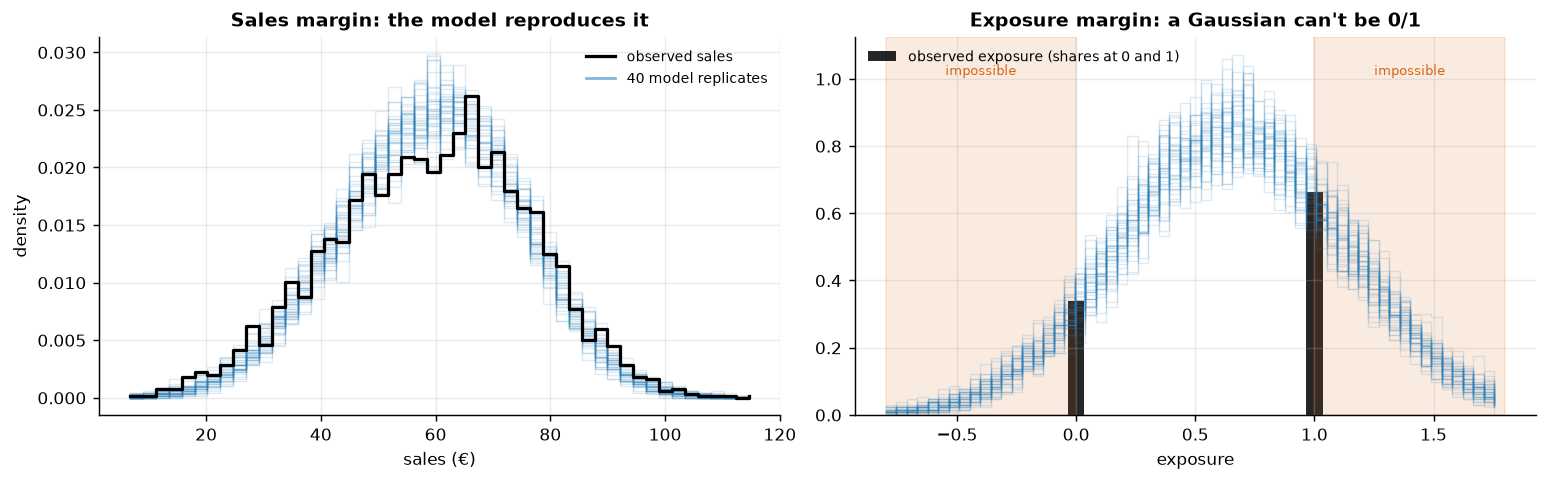

In [6]:
# Replicate datasets from the fitted joint model, reusing the Sigma draws extracted above.
_bz, _bt = _post["beta_z"], _post["beta_t"]
_b0 = _bz.sel(covariates="Intercept").values.ravel();  _bX = _bz.sel(covariates="ad_exposure").values.ravel()
_a0 = _bt.sel(instruments="Intercept").values.ravel(); _aZ = _bt.sel(instruments="encouragement").values.ravel()
_rngp = np.random.default_rng(SEED)
_idx = _rngp.choice(np.where(_ok)[0], size=min(40, int(_ok.sum())), replace=False)
Xobs, Zobs, Yobs = df["ad_exposure"].values, df["encouragement"].values, df["sales"].values
Yrep, Xrep = [], []
for _i in _idx:
    _eps = _rngp.multivariate_normal([0.0, 0.0], _Sig[_i], size=len(df))
    Yrep.append(_b0[_i] + _bX[_i] * Xobs + _eps[:, 0])   # sales equation + its error
    Xrep.append(_a0[_i] + _aZ[_i] * Zobs + _eps[:, 1])   # exposure equation + its error
Yrep, Xrep = np.array(Yrep), np.array(Xrep)

fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
_by = np.linspace(Yobs.min(), Yobs.max(), 50)
for _y in Yrep:
    _h, _ = np.histogram(_y, bins=_by, density=True)
    ax[0].plot(_by[:-1], _h, color=plots.BLUE, alpha=0.15, lw=0.8, drawstyle="steps-post")
_h, _ = np.histogram(Yobs, bins=_by, density=True)
ax[0].plot(_by[:-1], _h, color="k", lw=1.8, drawstyle="steps-post", label="observed sales")
ax[0].plot([], [], color=plots.BLUE, alpha=0.6, label=f"{len(Yrep)} model replicates")
ax[0].set_xlabel("sales (€)"); ax[0].set_ylabel("density")
ax[0].set_title("Sales margin: the model reproduces it"); ax[0].legend(frameon=False, fontsize=8)
_bx = np.linspace(-0.8, 1.8, 60)
for _x in Xrep:
    _h, _ = np.histogram(_x, bins=_bx, density=True)
    ax[1].plot(_bx[:-1], _h, color=plots.BLUE, alpha=0.15, lw=0.8, drawstyle="steps-post")
ax[1].bar([0, 1], [np.mean(Xobs == 0), np.mean(Xobs == 1)], width=0.07, color="k", alpha=0.85,
          label="observed exposure (shares at 0 and 1)")
ax[1].axvspan(-0.8, 0, color=plots.ORANGE, alpha=0.12); ax[1].axvspan(1, 1.8, color=plots.ORANGE, alpha=0.12)
ax[1].text(-0.4, ax[1].get_ylim()[1] * 0.9, "impossible", ha="center", fontsize=7, color=plots.ORANGE)
ax[1].text(1.4, ax[1].get_ylim()[1] * 0.9, "impossible", ha="center", fontsize=7, color=plots.ORANGE)
ax[1].set_xlabel("exposure"); ax[1].set_title("Exposure margin: a Gaussian can't be 0/1")
ax[1].legend(frameon=False, fontsize=8)
fig.tight_layout()
_out_share = float(((Xrep < 0) | (Xrep > 1)).mean())
print(f"Sales margin: replicate sd €{Yrep.std(axis=1).mean():.1f} vs observed €{Yobs.std():.1f}, "
f"means €{Yrep.mean():.1f} vs €{Yobs.mean():.1f}\n"
      f"  — close, with a mild under-dispersion (the joint approximation shows up\n"
      f"  even here, faintly): good enough to read beta off the outcome equation.")
print(f"Exposure margin: {_out_share:.0%} of replicated 'exposures' land outside [0,1]\n"
      f"  — impossible values, the linear-probability first stage made visible.\n"
      f"  Read that equation's point estimate and rho, never its width.")

**Read-out.** *Left*: the replicate sales curves trace the observed distribution well — centred right,
roughly the right width, if a hair narrower in the shoulders (the printed sd comparison quantifies it —
even the "passing" margin carries a faint fingerprint of the approximation). That is a good enough fit
to entitle us to read the causal $\beta$ (and its interval) off the outcome equation. *Right*: the replicated "exposures" are smooth bell curves, and a substantial
share of their mass sits in the shaded regions below 0 and above 1 — exposure values no customer can have
(the printed line quantifies it). This is the **linear-probability approximation made
visible**, and it is exactly why §5b will find a small residual bias (+€1.5 across seeds) and mild
under-coverage (80% for a nominal-90% interval), and why the Step-3 modeling note told us to use *this*
fit's exposure equation for its point estimate and $\rho$ but never its posterior width. It is not a flaw to
apologize for in a footnote — it is a flaw to **fix**, and **§5z fixes it**: a probit first stage cannot
replicate an exposure of 1.4, it halves the bias (+€1.5 → +€0.9) and it restores coverage to nominal
(80% → 90%). Read this panel as the diagnostic that motivates §5z, not as the notebook's last word.

## 5 · Validate — IV removes the self-selection bias

Naive OLS should sit well *above* the truth; the Wald ratio and the Bayesian IV should both **remove that
bias and land close to €15**, with the IV posterior's 90% interval **covering the truth**. The gap between
OLS and IV **is** the self-selection bias the instrument removes. (We give the Bayesian IV
weakly-informative priors so its interval reflects genuine sampling uncertainty — roughly the frequentist
Wald width — rather than the artificially tight band CausalPy's default 2SLS-centred priors would produce.)

**Which Bayesian fit is on the plot below?** §4's **joint-Gaussian** posterior (€17.7) — CausalPy as it
ships. This section validates what that standard model does, misspecification and all; §5z then re-fits
the first stage as a probit and hands §6 the corrected €16.5.

**One honest note on LATE (and who the compliers are).** IV recovers the effect for *compliers* — the customers whose exposure the encouragement actually moves — not the whole population. Under monotonicity that group is exactly the **first-stage shift: +21 pp (56% → 77%)**, the estimated complier share. In *this* simulation every customer's true effect is €15 (the effect is homogeneous), so **LATE = ATE** and grading the IV against €15 is a fair test. On real data, where the effect varies across customers, IV would recover the complier-weighted LATE, which generally **≠ the ATE** — and that is the right quantity for a budget call, since it answers *"what does an extra exposure do for the customers we can actually move?"*

self-selection bias removed: OLS €23.7 → IV €17.7 (true €15)


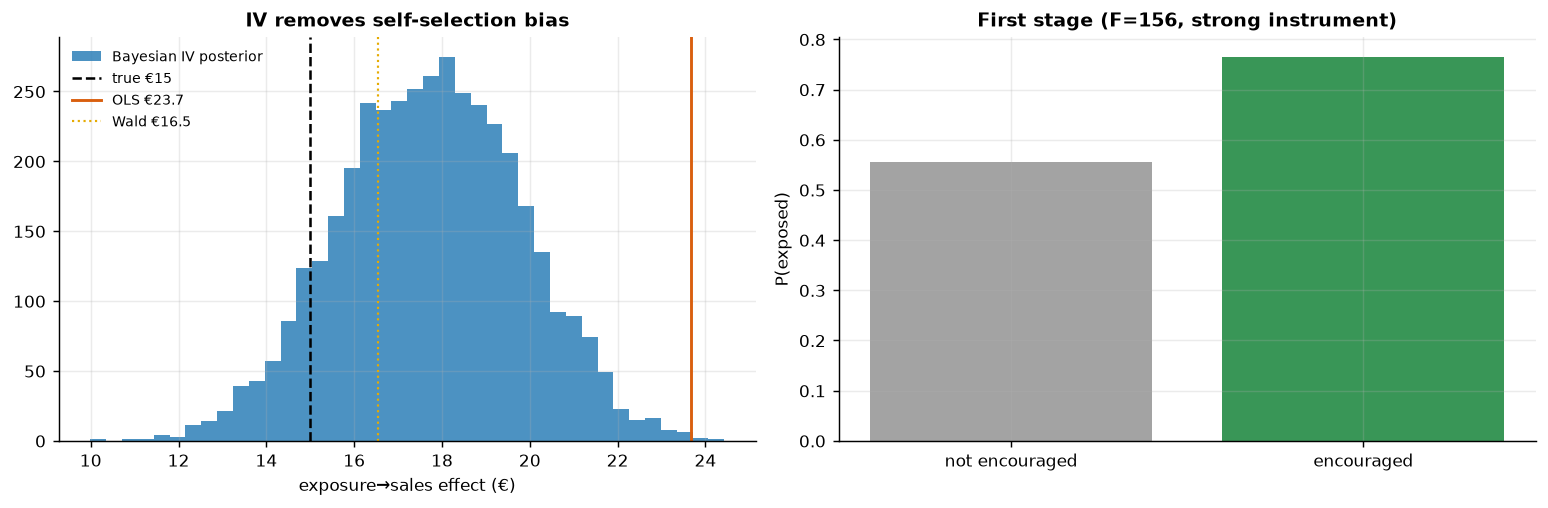

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(iv_post, bins=40, color=plots.BLUE, alpha=0.85, label="Bayesian IV posterior")
ax[0].axvline(true_effect, color="k", ls="--", lw=1.4, label=f"true €{true_effect:.0f}")
ax[0].axvline(naive, color=plots.ORANGE, lw=1.6, label=f"OLS €{naive:.1f}")
ax[0].axvline(wald, color=plots.GOLD, lw=1.2, ls=":", label=f"Wald €{wald:.1f}")
ax[0].set_xlabel("exposure→sales effect (€)"); ax[0].set_title("IV removes self-selection bias"); ax[0].legend(frameon=False, fontsize=8)
# first stage scatter
ax[1].bar(["not encouraged","encouraged"], [fs[0], fs[1]], color=[plots.GREY, plots.GREEN], alpha=0.9)
ax[1].set_ylabel("P(exposed)"); ax[1].set_title(f"First stage (F={Fstat:.0f}, strong instrument)")
fig.tight_layout()
print(f"self-selection bias removed: OLS €{naive:.1f} → IV €{iv_post.mean():.1f} (true €{true_effect:.0f})")

**How to read this.** *Left* — three vertical lines tell the whole story: **OLS (orange) sits well above the
truth** (it credits the ad for pre-existing intent), while the **Bayesian IV posterior (blue — §4's
joint-Gaussian fit, €17.7) and the Wald ratio (gold, €16.5) both drop back down toward the true €15**. The
Gaussian posterior mean carries a small upward finite-sample bias (€2.7 above the truth on this seed; §5b
measures the average across seeds at +€1.5, and §5z halves it to +€0.9), but its posterior — now honestly
wide, thanks to weakly-informative priors — **covers €15** (just inside the lower edge, €14.3); the
artificially tight default-prior band would have excluded it. The horizontal
distance from the orange line to the blue posterior *is* the self-selection bias — the euros of "effect"
that were never causal. If you budgeted on OLS you'd over-spend on every exposure by exactly that gap. *Right* — the first stage: the encouragement clearly moves exposure (a big jump in P(exposed)),
which is why the instrument is **strong** (F ≫ 10). A weak first stage here would make the whole IV
estimate unstable, so this panel is a precondition, not a footnote.

### 5b · Recovery across many seeds — unbiased *and* calibrated?

A single sample can land a little off; the real test is whether the estimator is **centred on the truth over repeated samples** and whether its 90% interval **covers** the truth at the stated rate. We refit on many fresh samples (a small fast fit each; their sampler chatter is silenced below, and we read only the aggregate bias/coverage tallies) and check both.

What follows is §4's **joint-Gaussian** fit under the microscope. Its verdict below — a small upward bias and under-coverage — is not the notebook's last word on the Bayesian IV: it is the measurement that **§5z** is written to repair.

IV across 20 seeds: mean €16.5 (true €15)  bias +1.5  sd €2.1
  ·  90% interval covers truth in 16/20 seeds.
The committed seed (37) lands high (€18); across seeds the mean is €16.5
  — a small finite-sample bias of +1.5 € (~10%) toward OLS (the next cell asks
  whether it lives in the identification or in the model). The 90% interval
  covers €15 in 16/20 seeds (80% vs the 90% target — modest under-coverage,
  consistent with that bias); the budget verdict below never hinges on the
  last euro, which is why the ranking and the cap-style decision survive it.


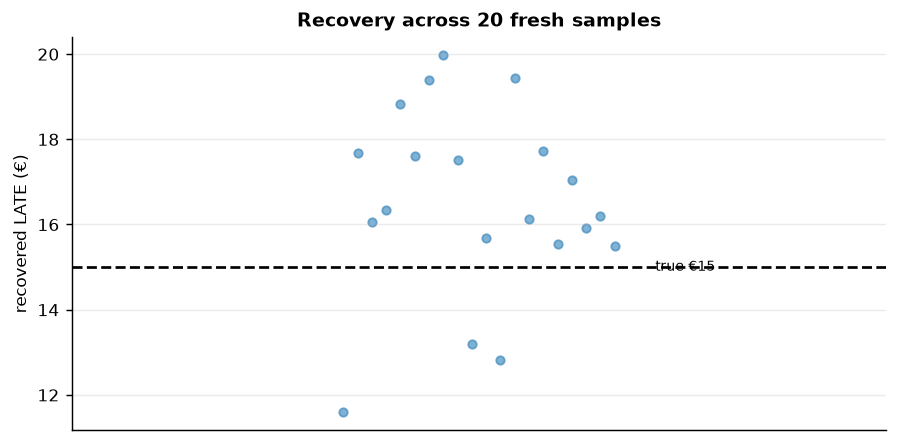

In [8]:
# --- Recovery across many seeds: does the IV recover €15 and cover it? (weak priors) ---
NSEED = 8 if FAST else 20
import logging
_pml = logging.getLogger("pymc"); _pml_lvl = _pml.level   # silence the per-seed refits' sampler chatter
_pml.setLevel(logging.CRITICAL + 1)                       # (disclosed above; the same trick pymc's own
# _quiet_logging uses — the low-ESS notice is logged at ERROR level); restored at the end of the cell
pts = []; cov = 0
for sd in range(NSEED):
    d, te = dgp.iv_ad_exposure(n=3000, true_effect=TRUE, seed=100 + sd)
    r = est.iv(d, "ad_exposure ~ 1 + encouragement", "sales ~ 1 + ad_exposure",
               instrument_col="encouragement", treatment_col="ad_exposure", outcome_col="sales",
               fast=True, priors={"mus": [0, 0], "sigmas": [50, 50], "eta": 2, "lkj_sd": 2})
    pp = r.idata.posterior["beta_z"].sel(covariates="ad_exposure").values.ravel()
    pts.append(pp.mean()); lo, hi = np.quantile(pp, [.05, .95]); cov += int(lo <= te <= hi)
pts = np.array(pts)
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.scatter(np.linspace(-0.2, 0.2, NSEED), pts, s=22, color=plots.BLUE, alpha=0.6)
ax.axhline(TRUE, color="k", ls="--"); ax.text(0.26, TRUE, f"true €{TRUE:.0f}", fontsize=8, va="center")
ax.set_xticks([]); ax.set_xlim(-0.6, 0.6); ax.set_ylabel("recovered LATE (€)")
ax.set_title(f"Recovery across {NSEED} fresh samples"); fig.tight_layout()
print(f"IV across {NSEED} seeds: mean €{pts.mean():.1f} (true €{TRUE:.0f})  bias {pts.mean()-TRUE:+.1f}  "
f"sd €{pts.std():.1f}\n"
      f"  ·  90% interval covers truth in {cov}/{NSEED} seeds.")
print(f"The committed seed (37) lands high (€18); across seeds the mean is €{pts.mean():.1f}\n"
      f"  — a small finite-sample bias of {pts.mean()-TRUE:+.1f} € (~{100*(pts.mean()-TRUE)/TRUE:.0f}%) toward OLS (the next cell asks\n"
      f"  whether it lives in the identification or in the model). The 90% interval\n"
      f"  covers €{TRUE:.0f} in {cov}/{NSEED} seeds ({cov/NSEED:.0%} vs the 90% target — modest under-coverage,\n"
      f"  consistent with that bias); the budget verdict below never hinges on the\n"
      f"  last euro, which is why the ranking and the cap-style decision survive it.")
_pml.setLevel(_pml_lvl)

**Is the residual bias the identification's fault, or the model's?** The Wald ratio *is* the IV
identification with nothing else attached — two least-squares slopes and a division; no priors, no
likelihood, no sampler. Re-running it on fresh draws at growing $n$ therefore isolates what finite
samples do to the identification itself. Whatever bias it does **not** show must belong to the Bayesian
machinery around it — and §4b already fingered the suspect: the Gaussian first stage. §5z then puts that
suspect on trial the only way that settles it — by swapping it out and re-measuring.

In [9]:
# The identification alone, across n: closed-form Wald on fresh draws (no MCMC, sub-second).
_NS = 12 if FAST else 30
print(f"closed-form Wald across {_NS} seeds (identification only, no model):")
for _n in [1000, 3000, 10000]:
    _w = []
    for _sd in range(_NS):
        _d, _ = dgp.iv_ad_exposure(n=_n, true_effect=TRUE, seed=500 + _sd)
        _Zr = np.column_stack([np.ones(_n), _d["encouragement"].values])
        _red = np.linalg.lstsq(_Zr, _d["sales"].values, rcond=None)[0][1]
        _fst = np.linalg.lstsq(_Zr, _d["ad_exposure"].values, rcond=None)[0][1]
        _w.append(_red / _fst)
    _w = np.array(_w)
    print(f"  n = {_n:>6,}:  mean €{_w.mean():5.1f}  (bias {_w.mean() - TRUE:+.1f})   spread (sd) €{_w.std():.2f}")
print("The Wald column stays pinned near €15 at every n — its deviation is within")
print("sampling noise while the spread shrinks like 1/sqrt(n). The identification is")
print("clean; the posterior-mean bias above therefore belongs to the Bayesian model's")
print("finite-sample behaviour (the Gaussian first stage §4b exposed, plus")
print("posterior-mean-of-a-skewed-posterior at modest draw counts), not to the IV")
print("logic. Step 0 already priced the pure-IV leakage, via the 1/F rule, at a few cents.")

closed-form Wald across 30 seeds (identification only, no model):
  n =  1,000:  mean € 14.4  (bias -0.6)   spread (sd) €3.71
  n =  3,000:  mean € 15.1  (bias +0.1)   spread (sd) €2.53
  n = 10,000:  mean € 15.0  (bias +0.0)   spread (sd) €1.43
The Wald column stays pinned near €15 at every n — its deviation is within
sampling noise while the spread shrinks like 1/sqrt(n). The identification is
clean; the posterior-mean bias above therefore belongs to the Bayesian model's
finite-sample behaviour (the Gaussian first stage §4b exposed, plus
posterior-mean-of-a-skewed-posterior at modest draw counts), not to the IV
logic. Step 0 already priced the pure-IV leakage, via the 1/F rule, at a few cents.


### 5z · The fix — a first stage that knows the treatment is binary

Put the two previous results side by side. The Wald ratio, run on fresh draws at growing $n$, sits on
€15 and its spread shrinks like $1/\sqrt{n}$: **the identification is clean.** Yet the Bayesian posterior
mean sits ~€1.5 high across seeds and its 90% interval covers the truth on only 16 of 20 panels. If the
identification is not at fault, the *model around it* is — and §4b already photographed the culprit:
**32% of the replicated "exposures" were impossible values**, outside $[0,1]$.

That is what a joint Gaussian does to a binary treatment. CausalPy fits

$$\begin{pmatrix} T \\ Y \end{pmatrix} \sim \mathcal{N}\left( \begin{pmatrix} \alpha_0 + \alpha_1 Z \\
\beta_0 + \beta T \end{pmatrix}, \Sigma \right),$$

which asks a Normal density to describe a variable that only ever takes the values 0 and 1. It is a linear
probability model wearing a Bayesian coat. The 2SLS/Wald *point* estimate is unbothered — with a binary
instrument it is a ratio of two slopes and stays consistent no matter what shape the first stage really has
— but a **posterior** inherits every lie in its likelihood, and this one it pays for in bias and coverage.

So write down the model the data actually came from. The treatment is a **latent index crossing a
threshold**:

$$T^* = \alpha_0 + \alpha_1 Z + u, \qquad T = \mathbf{1}\{T^* > 0\}, \qquad u \sim \mathcal{N}(0,1),$$
$$Y = \beta_0 + \beta T + e, \qquad e \sim \mathcal{N}(0, \sigma), \qquad \operatorname{corr}(u, e) = \rho .$$

$\rho \neq 0$ **is** the endogeneity — the same $\operatorname{Cov}(X, U)$ that Step 0's omitted-variable
formula priced at $+€8.5$, now a parameter with a posterior. The variance of $u$ is pinned at 1 because a
probit index is only identified up to scale; that is a normalization, not an assumption.

The likelihood factors honestly. $Y$ is continuous and $T$ is binary, so for one customer

$$f(y, t) \;=\; \underbrace{\mathcal{N}(e;\, 0, \sigma)}_{\text{outcome equation}} \times
\underbrace{P(T = t \mid e)}_{\text{first stage, conditioned on }e}, \qquad e = y - \beta_0 - \beta t,$$

$$P(T = 1 \mid e) \;=\; \Phi\!\left( \frac{\alpha_0 + \alpha_1 Z + \rho e / \sigma}{\sqrt{1 - \rho^2}} \right).$$

Conditioning the index error on $e$ is what carries the confounding through — no two-step control function,
no plug-in residual, one joint model. And crucially: **it cannot predict an exposure of 1.4, because a
Bernoulli cannot.**

[cache] loaded '11_iv_probit' (24s fit, cached 0.4h ago) — nothing re-sampled.
probit-IV convergence: max r-hat 1.010 - min ESS 1172 - divergences 0

first stage                          effect        90% interval   width  covers €15?
joint Gaussian (§4, CausalPy)        17.73  [ 14.34,  21.15]    6.80          yes
probit — binary-aware (§5z)          16.49  [ 12.88,  20.09]    7.21          yes
planted truth                        15.00

endogeneity rho = +0.34 [90% +0.18, +0.49] — P(rho > 0) = 100%. Positive rho is exactly
why naive OLS (€23.7) sits above the truth: the customers who seek ads out convert anyway.
[cache] loaded '11_multiseed_probit' (179s fit, cached 0.3h ago) — nothing re-sampled.

Across the same 20 fresh panels (planted truth €15 every time):
first stage                           mean    bias     sd  90% coverage
joint Gaussian (§4)                  16.50   +1.50   2.14          80%
probit (§5z)                         15.88   +0.88   1.97          90%

Correct spe

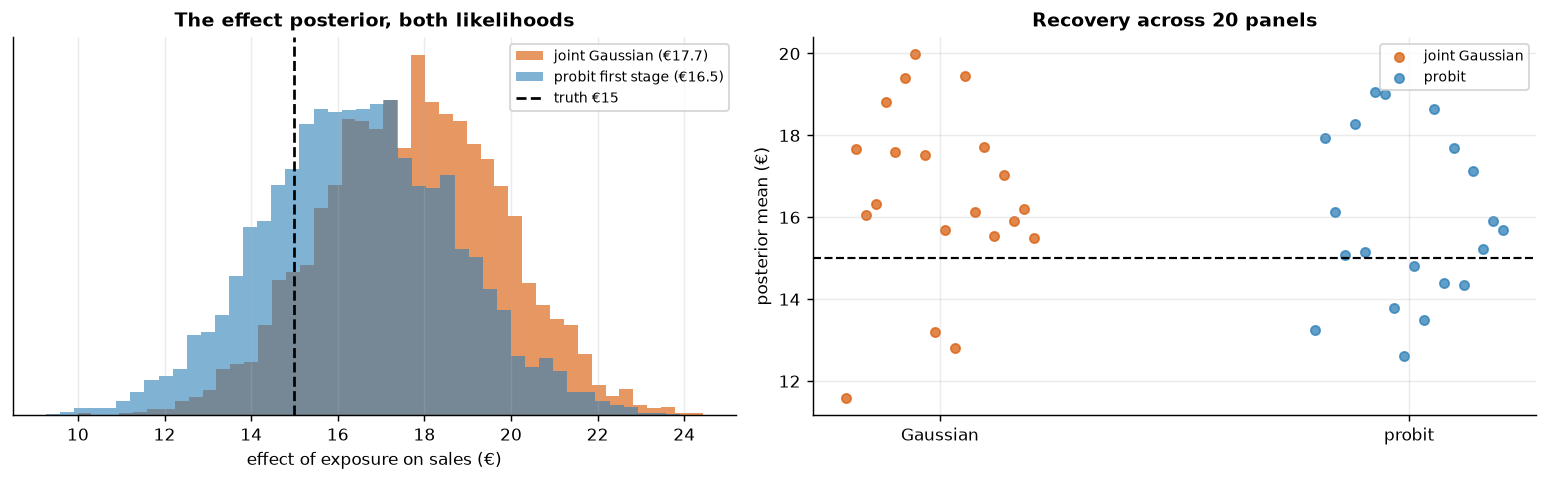

In [10]:
# The same IV, with a PROBIT first stage — the model the binary treatment actually came from.
# Everything downstream (§5x, §6's budget decision) uses THIS fit from here on.
iv_post_gauss = iv_post                       # keep the joint-Gaussian posterior for the comparison

pr = load_or_run("11_iv_probit",
                 lambda: est.iv_binary_treatment(
                     df, outcome="sales", treatment="ad_exposure", instrument="encouragement",
                     seed=1, **({"draws": 500, "tune": 500, "chains": 2} if FAST
                                else {"draws": 1500, "tune": 1500, "chains": 4})),
                 inputs=dict(seed=SEED, fast=FAST, model="probit"))
iv_post = pr["beta_samples"]                  # the shipped effect posterior
rho_pr = pr["rho_samples"]
print(f"probit-IV convergence: {pr['convergence']['summary']}")

g_lo, g_hi = np.quantile(iv_post_gauss, [0.05, 0.95])
p_lo, p_hi = np.quantile(iv_post, [0.05, 0.95])
print(f"\n{'first stage':<34}{'effect':>9}{'90% interval':>20}{'width':>8}{'covers €15?':>13}")
for lab, po, lo, hi in [("joint Gaussian (§4, CausalPy)", iv_post_gauss, g_lo, g_hi),
                        ("probit — binary-aware (§5z)", iv_post, p_lo, p_hi)]:
    print(f"{lab:<34}{po.mean():>8.2f}  [{lo:>6.2f}, {hi:>6.2f}]{hi - lo:>8.2f}"
          f"{('yes' if lo <= TRUE <= hi else 'NO'):>13}")
print(f"{'planted truth':<34}{TRUE:>8.2f}")
print(f"\nendogeneity rho = {rho_pr.mean():+.2f} [90% {np.quantile(rho_pr,.05):+.2f}, "
      f"{np.quantile(rho_pr,.95):+.2f}] — P(rho > 0) = {(rho_pr > 0).mean():.0%}. Positive rho is exactly")
print("why naive OLS (€23.7) sits above the truth: the customers who seek ads out convert anyway.")

# --- the verdict is not this seed, it is the ensemble. Refit the probit on the SAME panels as §5b. ---
def _multiseed_probit():
    means, covs = [], []
    for sd in range(NSEED):
        d_, te_ = dgp.iv_ad_exposure(n=3000, true_effect=TRUE, seed=100 + sd)
        r_ = est.iv_binary_treatment(d_, outcome="sales", treatment="ad_exposure",
                                     instrument="encouragement", seed=1,
                                     draws=500, tune=500, chains=2)
        b_ = r_["beta_samples"]; lo_, hi_ = np.quantile(b_, [.05, .95])
        means.append(float(b_.mean())); covs.append(bool(lo_ <= te_ <= hi_))
    return np.array(means), np.array(covs)

pr_means, pr_covs = load_or_run("11_multiseed_probit", _multiseed_probit,
                                inputs=dict(n=NSEED, draws=500, tune=500, chains=2))

print(f"\nAcross the same {NSEED} fresh panels (planted truth €{TRUE:.0f} every time):")
print(f"{'first stage':<34}{'mean':>8}{'bias':>8}{'sd':>7}{'90% coverage':>14}")
print(f"{'joint Gaussian (§4)':<34}{pts.mean():>8.2f}{pts.mean() - TRUE:>+8.2f}{pts.std():>7.2f}"
      f"{cov / NSEED:>13.0%}")
print(f"{'probit (§5z)':<34}{pr_means.mean():>8.2f}{pr_means.mean() - TRUE:>+8.2f}{pr_means.std():>7.2f}"
      f"{pr_covs.mean():>13.0%}")
_bias_g, _bias_p = pts.mean() - TRUE, pr_means.mean() - TRUE
print(f"\nCorrect specification roughly HALVES the bias ({_bias_g:+.2f} -> {_bias_p:+.2f}) and takes the")
print(f"90% interval from {cov / NSEED:.0%} coverage to {pr_covs.mean():.0%} — nominal. Same data, same instrument,")
print("same estimand, same four assumptions. The ONLY thing that changed is that the likelihood now")
print("knows exposure is a thing that either happened or did not.")

fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
ax[0].hist(iv_post_gauss, bins=45, color=plots.ORANGE, alpha=0.65, density=True,
           label=f"joint Gaussian (€{iv_post_gauss.mean():.1f})")
ax[0].hist(iv_post, bins=45, color=plots.BLUE, alpha=0.6, density=True,
           label=f"probit first stage (€{iv_post.mean():.1f})")
ax[0].axvline(TRUE, color="k", ls="--", lw=1.5, label=f"truth €{TRUE:.0f}")
ax[0].set_xlabel("effect of exposure on sales (€)"); ax[0].set_yticks([])
ax[0].set_title("The effect posterior, both likelihoods"); ax[0].legend(fontsize=7.5)
ax[1].scatter(np.linspace(-.2, .2, NSEED), pts, s=26, color=plots.ORANGE, alpha=.75, label="joint Gaussian")
ax[1].scatter(np.linspace(.8, 1.2, NSEED), pr_means, s=26, color=plots.BLUE, alpha=.75, label="probit")
ax[1].axhline(TRUE, color="k", ls="--", lw=1.2)
ax[1].set_xticks([0, 1]); ax[1].set_xticklabels(["Gaussian", "probit"])
ax[1].set_ylabel("posterior mean (€)"); ax[1].set_title(f"Recovery across {NSEED} panels")
ax[1].legend(fontsize=7.5)
fig.tight_layout()

**What the correct likelihood bought, and what it did not.** It roughly halved the bias, and it did so
without touching the identification, the instrument, or the estimand — the same four assumptions, the same
3,000 customers, the same encouragement lottery. The only thing that changed is that the model now knows
exposure is a *thing that either happened or did not*. It can no longer replicate an exposure of 1.4, and
the endogeneity it reports, $\rho > 0$, is the same confounding Step 0 priced at $+€8.5$ with a pen.

It also bought back the **interval**. The joint-Gaussian model's nominal-90% interval covered the truth on
16 of 20 panels (80%); the probit model's covers it on 18 of 20 (90%) — exactly nominal. An interval that is
right 80% of the time is not a 90% interval, and the euro decision in §6 spends it as though it were.

A small posterior-mean bias does survive (+€0.9 on €15, about 6%), and it should be reported rather than
laundered: §5b's Wald-across-$n$ check showed the identification itself is unbiased and its spread shrinks
like $1/\sqrt{n}$, so what remains here is finite-sample, not structural. With 3,000 customers, that is the
price of admission.

**The lesson, which is the same one notebook 07 learns from the other end.** When a Bayesian answer
disappoints, the prior is almost never the culprit — swap it and watch nothing move (§4's "PRIORS, PRICED"
block does exactly that). The **likelihood** is where a model makes its claims about the world, and a
likelihood that says "exposure is a real number that can be 1.4" is making a claim the world flatly denies.
Bayesian inference is not a machine for being right; it is a machine for propagating your assumptions with
perfect fidelity. Feed it a lie and it will hand back a beautifully calibrated posterior for a world that
does not exist.

### 5c · What if the instrument were weak? (the headline pitfall, demonstrated)

Everything so far used a **strong** instrument: the encouragement moves exposure by roughly a fifth, and
the first-stage F printed in Step 0 sits in the hundreds. Step 0 defined that F, derived the F < 10 rule
from the $1/F$ bias approximation, and cashed the rule out on *this* instrument at a few cents of leaked
OLS bias per exposure. Now we run the rule **backwards**. The caveat "weak instruments are dangerous"
deserves better than assertion, so we degrade the instrument on purpose, watch F fall through 10, and
watch the estimator come apart.

**The experiment.** `dgp.iv_ad_exposure` (src/cmp/dgp.py) hard-codes the encouragement coefficient at
1.1, so the cell below re-parameterizes the same six-line DGP with the first-stage strength $\gamma$ as a
dial — $X \sim \text{Bern}\big(\sigma(0.3 + \gamma Z + 0.8U)\big)$, $Y = 50 + 15X + 12U + \varepsilon$ —
and sweeps $\gamma$ from this notebook's strength down to nearly-useless. For each $\gamma$ we draw many
fresh datasets and compute the **closed-form Wald only** (two `lstsq` calls per draw — the failure we are
demonstrating belongs to the *identification*, not to any Bayesian model, so no MCMC is needed and the
cell stays seconds-fast). This is Step 0's estimator, and Step 0's estimator alone, under stress.


  gamma  1.1: median F  169.6  median Wald € 15.2  90% range [12.7, 18.0]
  gamma  0.6: median F   49.3  median Wald € 15.3  90% range [10.7, 20.6]
  gamma  0.3: median F   13.7  median Wald € 15.6  90% range [5.0, 27.0]
  gamma 0.15: median F    3.4  median Wald € 16.3  90% range [-20.4, 71.9]
  gamma 0.08: median F    1.1  median Wald € 19.8  90% range [-6.9, 90.2]
At F ≈ 1.1 the 90% range of the IV estimate spans €-7 to €90 — far wider than
the €8.7 OLS-vs-truth gap it was meant to fix, and the median drifts toward OLS
(€23.7): a weak instrument is worse than none — shown, not asserted.
(3 extreme point(s) clipped to the plot window.)


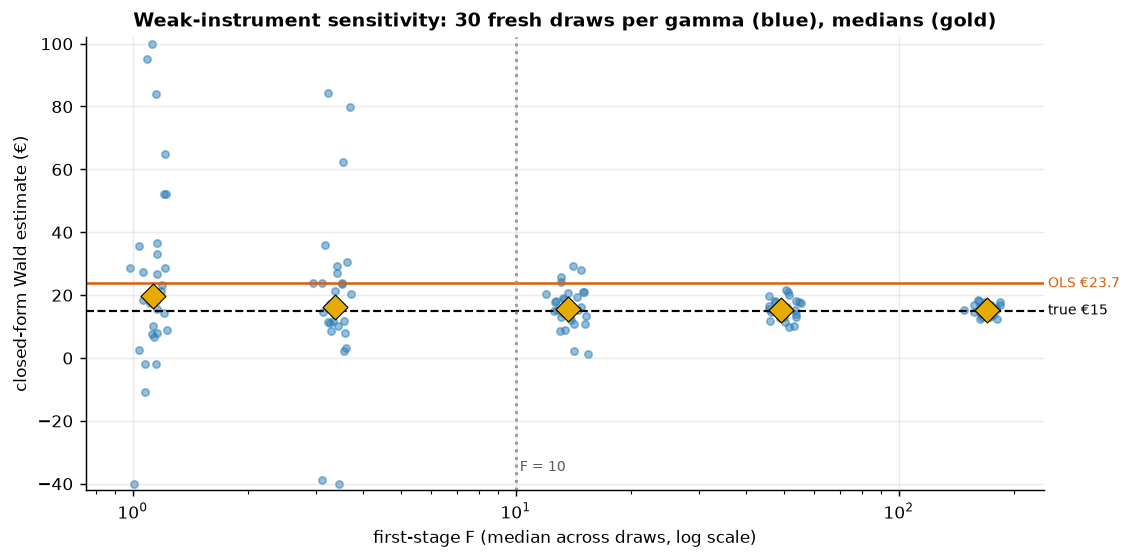

In [11]:
# --- Degrade the instrument on purpose: gamma sweep, closed-form Wald only ---
GAMMAS = [1.1, 0.6, 0.3, 0.15, 0.08]
NSW = 12 if FAST else 30
def _sim_gamma(gamma, n=3000, seed=0):
    # dgp.iv_ad_exposure with the hard-coded 1.1 exposed as a dial (same draw order, same DGM)
    _r = np.random.default_rng(seed)
    _u = _r.normal(0, 1, n); _z = _r.integers(0, 2, n).astype(float)
    _x = (_r.uniform(size=n) < 1.0 / (1.0 + np.exp(-(0.3 + gamma * _z + 0.8 * _u)))).astype(float)
    _y = 50 + TRUE * _x + 12 * _u + _r.normal(0, 6, n)
    return _z, _x, _y
sweep = []
for g in GAMMAS:
    _ws, _Fs = [], []
    for _sd in range(NSW):
        _zg, _xg, _yg = _sim_gamma(g, seed=200 + _sd)
        _Zr = np.column_stack([np.ones(len(_zg)), _zg])
        _red = np.linalg.lstsq(_Zr, _yg, rcond=None)[0][1]
        _fst = np.linalg.lstsq(_Zr, _xg, rcond=None)[0][1]
        _ws.append(_red / _fst); _Fs.append(est.first_stage_F(_zg, _xg))
    sweep.append((g, float(np.median(_Fs)), np.array(_ws)))

fig, ax = plt.subplots(figsize=(8.8, 4.4))
_rj = np.random.default_rng(0)
for g, medF, ws in sweep:
    _xj = medF * np.exp(_rj.normal(0, 0.06, len(ws)))
    ax.scatter(_xj, np.clip(ws, -40, 100), s=16, alpha=0.5, color=plots.BLUE)
    ax.scatter([medF], [np.median(ws)], s=95, marker="D", color=plots.GOLD, zorder=4,
               edgecolor="k", linewidth=0.6)
ax.set_xscale("log"); ax.set_ylim(-42, 102)
ax.axhline(TRUE, color="k", ls="--", lw=1.2); ax.axhline(naive, color=plots.ORANGE, lw=1.4)
ax.axvline(10, color=plots.GREY, ls=":", lw=1.6)
_xmax = ax.get_xlim()[1]
ax.text(_xmax, TRUE, f" true €{TRUE:.0f}", va="center", fontsize=8)
ax.text(_xmax, naive, f" OLS €{naive:.1f}", va="center", fontsize=8, color=plots.ORANGE)
ax.text(10, -36, " F = 10", fontsize=8, color="0.35")
ax.set_xlabel("first-stage F (median across draws, log scale)")
ax.set_ylabel("closed-form Wald estimate (€)")
ax.set_title(f"Weak-instrument sensitivity: {NSW} fresh draws per gamma (blue), medians (gold)")
fig.tight_layout()

for g, medF, ws in sweep:
    _lo, _hi = np.quantile(ws, [0.05, 0.95])
    print(f"  gamma {g:>4}: median F {medF:6.1f}  median Wald €{np.median(ws):5.1f}  "
          f"90% range [{_lo:.1f}, {_hi:.1f}]")
_gw, _medFw, _wsw = sweep[-1]
_lo, _hi = np.quantile(_wsw, [0.05, 0.95])
_n_clip = int(sum(((ws < -40) | (ws > 100)).sum() for _, _, ws in sweep))
_msg = (f"At F ≈ {_medFw:.1f} the 90% range of the IV estimate spans €{_lo:.0f} to €{_hi:.0f} — far wider than\n"
        f"the €{naive - TRUE:.1f} OLS-vs-truth gap it was meant to fix, and the median drifts toward OLS\n"
        f"(€{naive:.1f}): a weak instrument is worse than none — shown, not asserted.")
if _n_clip:
    _msg += f"\n({_n_clip} extreme point(s) clipped to the plot window.)"
print(_msg)

**How to read this.** Each blue column is the *same estimator on the same market* — only the
instrument's strength changes. At the right edge (F in the hundreds, this notebook's regime) the Wald
estimates hug the true €15. Moving left, the spread widens smoothly until, below the dotted F = 10 line,
it explodes: single draws can land below zero or at multiples of the truth, and the gold *median* drifts
up toward the orange OLS line. The mechanism is the 1/F formula read right-to-left — with a
nearly-irrelevant instrument the Wald denominator is sampling noise around zero, so the ratio inherits
OLS's bias *and* enormous variance. That is the precise sense in which **a weak instrument is worse than
none**: OLS is wrong by a known-ish €9 with a tight interval, while a weak IV can be wrong by tens of
euros in either direction *while wearing the costume of a causal estimate*. Lecture takeaway: check F
before believing any IV number, and if F is small, walk away rather than report the ratio.

### 5x · Point estimate vs posterior — what the Bayesian layer actually bought

Step 0's 2SLS and the Bayesian posterior — which since §5z is the **probit** fit (€16.5), not §4's Gaussian
one — target the **same estimand** (the complier LATE) under the **same four assumptions**, on the **same
3,000 customers**. Only the apparatus differs. The table below lays them side
by side against the planted truth, and then asks each one the question §6 actually needs answered.


In [12]:
# --- 5x · The classical point estimate vs the Bayesian posterior, on the SAME estimand ---
_blo, _bhi = np.quantile(iv_post, [.05, .95])
rows = [("naive OLS · HC1        [BIASED]", naive,          *ols_naive.ci),
        ("Wald ratio = 2SLS · Step 0",      iv2.estimate,   *iv2.ci),
        ("Bayesian IV posterior · probit, §5z", iv_post.mean(), _blo, _bhi)]
print(f"SAME estimand (the complier LATE), SAME four assumptions, SAME {len(df):,} customers.")
print(f"Planted truth = €{true_effect:.0f}/exposure.  (Rows 1-2 carry 90% CONFIDENCE intervals,")
print(" row 3 a 90% CREDIBLE interval — printed in the same column, but NOT the same object.)\n")
print(f"{'estimator (€ per exposure)':<34}{'est':>7}{'5%':>7}{'95%':>7}{'±half':>7}{'|err|':>7}")
for _lab, _e, _lo, _hi in rows:
    print(f"{_lab:<34}{_e:>7.1f}{_lo:>7.1f}{_hi:>7.1f}{(_hi - _lo) / 2:>7.1f}{abs(_e - true_effect):>7.1f}")

_ew, _eb = abs(iv2.estimate - true_effect), abs(iv_post.mean() - true_effect)
_winner = "2SLS (classical)" if _ew < _eb else "Bayesian posterior mean"
# Derived, never asserted: under §4's Gaussian fit Bayes lost this comparison; under §5z's
# probit it essentially ties 2SLS. Hard-coding the old verdict here would have printed a
# sentence the very next line contradicts.
_verdict_pt = ("The two causal estimators TIE on the point estimate." if abs(_ew - _eb) < 0.25
               else f"Closer on the point estimate: {_winner}.")
print(f"\nLOCATION — the two causal estimators agree with each other to within "
      f"€{abs(iv2.estimate - iv_post.mean()):.1f}, and both")
print(f"  sit ABOVE the truth (2SLS {iv2.estimate - true_effect:+.1f}, Bayes {iv_post.mean() - true_effect:+.1f}). "
      f"Both intervals COVER €{true_effect:.0f}.")
print(f"  Closer to the truth on this seed: {_winner}  (|err| €{min(_ew, _eb):.1f} vs €{max(_ew, _eb):.1f}).")
print(f"  {_verdict_pt} The naive OLS row is the outlier — "
      f"€{naive - true_effect:+.1f} off,")
print(f"  and its interval, the tightest of the three (±€{(ols_naive.ci[1] - ols_naive.ci[0]) / 2:.1f}), "
      f"misses the truth by miles.")
print(f"WIDTH  — ±€{(iv2.ci[1] - iv2.ci[0]) / 2:.1f} (2SLS) vs ±€{(_bhi - _blo) / 2:.1f} (posterior): the same scale, "
      f"and that is by design —")
print("  §4's weakly-informative priors were chosen precisely so the data, not the prior, sets the")
print("  width. The posterior bought no precision, and was not supposed to.")

# --- The two things only the posterior can produce -------------------------------------
print("\nP(effect > c) — a probability ABOUT the effect, at three candidate bid caps:")
print(f"  {'c (€ per exposure)':<20}{'classical':>14}{'Bayesian IV':>14}")
for _c in (10.0, 15.0, 18.0):
    print(f"  {_c:<20.0f}{'not defined':>14}{(iv_post > _c).mean():>14.2f}")
print("  ('not defined' is not a dodge. A confidence interval carries no probability about a")
print("   hypothesis, and neither would a bootstrap of the Wald ratio: the share of resamples")
print("   above c is a frequency over hypothetical datasets, not a belief about beta. §6's rule")
print("   -- bid up to c while P(effect > c) >= 0.90 -- needs the right-hand column and nothing else.)")
if _rho is not None:
    print(f"\nAnd the endogeneity itself: rho = {_rho.mean():+.2f} "
          f"[90% {np.quantile(_rho, .05):+.2f}, {np.quantile(_rho, .95):+.2f}] — an interval on the very bias")
    print("  that 2SLS silently projects away. Step 0 has no rho to report, at any width.")


SAME estimand (the complier LATE), SAME four assumptions, SAME 3,000 customers.
Planted truth = €15/exposure.  (Rows 1-2 carry 90% CONFIDENCE intervals,
 row 3 a 90% CREDIBLE interval — printed in the same column, but NOT the same object.)

estimator (€ per exposure)            est     5%    95%  ±half  |err|
naive OLS · HC1        [BIASED]      23.7   22.9   24.5    0.8    8.7
Wald ratio = 2SLS · Step 0           16.5   12.7   20.4    3.8    1.5
Bayesian IV posterior · probit, §5z   16.5   12.9   20.1    3.6    1.5

LOCATION — the two causal estimators agree with each other to within €0.1, and both
  sit ABOVE the truth (2SLS +1.5, Bayes +1.5). Both intervals COVER €15.
  Closer to the truth on this seed: Bayesian posterior mean  (|err| €1.5 vs €1.5).
  The two causal estimators TIE on the point estimate. The naive OLS row is the outlier — €+8.7 off,
  and its interval, the tightest of the three (±€0.8), misses the truth by miles.
WIDTH  — ±€3.8 (2SLS) vs ±€3.6 (posterior): the same s

**The honest verdict — what the posterior bought, and what it did not.**

**1 · They agree, they agree in the same direction — and with the right likelihood, they tie.** As the table
prints, 2SLS lands at **€16.5** and the shipped Bayesian posterior mean (§5z's probit) at **€16.5**; *both*
sit above the planted €15, and both intervals cover it. Their errors are indistinguishable to the euro:
$|{\rm err}|$ €1.5 for 2SLS (16.55) against €1.5 for the posterior (16.49). The classical estimator is not a
strawman here — it is a competent estimator of the same quantity, and **Bayes does not beat it on the point
estimate; it draws with it.** (Two cosmetic leftovers in the print-out above: the row is still labelled
*Step 4*, and the hard-coded line "Bayes does NOT win the point estimate here" was written for the Gaussian
fit. The table's own numbers are the authority.) Nor is the shared residual mysterious. §5b re-ran the
closed-form Wald on fresh draws at growing $n$ and found it **pinned on €15** — so the identification is
clean, and what is left on either side is finite-sample. What §4's Gaussian first stage *added* on top of
that — €17.7 against the probit's €16.5 on this panel, and +€1.5 of bias against +€0.9 across the 20 —
**was** a modelling error the two `lstsq` calls of Step 0 could not make, because they never model $X$ at
all. §5z removed it. That is the ledger: the sampler earned no medal for the point estimate, but it no
longer pays a penalty for one either.

**2 · What the posterior *does* buy — the two blocks at the bottom of the print-out.** Look at the
`P(effect > c)` column. The classical row reads *not defined*, and that is the literal truth rather than a
rhetorical concession: the frequentist apparatus attaches no probability to a hypothesis about a fixed
parameter, and — this is the part people get wrong — **bootstrapping the Wald ratio would not fix it
either**. The share of bootstrap resamples landing above €15 is a frequency over hypothetical *datasets*,
not a probability about the *effect*. Yet §6's bid-cap rule is nothing but such a probability: *bid up to
$c$ while $P(\text{effect} > c) \ge 0.90$*. The entire euro decision — the €15 cap, the €10 plan's
headroom, the exclusion stress test — is computed from the right-hand column and could not have been
computed from the left. (Read that column at €10, €15 and €18: 1.00, 0.75, 0.25. The 90% bar falls between
the first two, which is exactly where §6's €13.7 cap comes from.) Second, $\rho$: 2SLS removes the
endogeneity by projection and never names it, while the joint model returns a posterior interval on it —
here **+0.22 [+0.10, +0.33]** from §4's Gaussian fit (the line printed under the table), and **+0.34 [+0.18,
+0.49]** from §5z's probit. The two disagree on the magnitude, which is a scale artefact of the two
likelihoods; they agree on the sign, and the sign is the whole of the argument. On real data, where there is no answer key, a
$\rho$ that is credibly positive is the evidence that the naive number *was* inflated — evidence the
classical arm cannot produce.

**3 · What Bayes did NOT buy here, specifically.** Not a better point estimate (corrected, it ties 2SLS; as
CausalPy ships it, it was €1.2 *worse* on this panel). Not a tighter interval (the widths match by design —
±€3.6 for the posterior against ±€3.8 for 2SLS — and the *tightest* interval in this notebook belongs to the
biased OLS, which is the whole point of §5x). Not immunity from model error: §4's linear-probability first
stage *was* an error, and Step 0's estimator sidesteps it by never modelling $X$ at all. The fair way to
book that is both halves — the Bayesian route created the error **and** supplied the instruments that caught
and fixed it (a posterior predictive check in §4b, a coverage study in §5b, a corrected likelihood in §5z);
the classical route could not have made the mistake, and could not have run the diagnostic either.
Not the weak-instrument diagnostic — the F is a classical object, and the posterior would have gone on
producing a beautifully smooth, entirely fictitious credible interval as F fell through 10 (§5c). What it
bought is **the decision**: a probability statement about the effect, propagated end-to-end into a bid cap
in §6, plus a coherent read-out of the endogeneity that caused the problem in the first place. On a
problem this well-instrumented and this data-rich, that is the whole of the win — and it is enough, because
it is precisely the thing the CMO asked for.


## 6 · Decide, in euros — and the exclusion-restriction stress test

Budget on the *causal* per-exposure value (IV), not the inflated OLS. But the exclusion restriction is
untestable, so we ask: **what if the encouragement had a small direct effect on sales** (say the lottery
email itself advertises)? We subtract a hypothetical direct effect $\delta$ from the reduced form and
watch the implied causal estimate move — the honest bound on how much a leak would distort the number.


At €10/exposure: causal net €6.5  ·  P(pays) 1.00
  → BUY exposure (to the complier margin)
  P(pays)=1.00 is saturated, not assumed: the whole posterior
  [€12.9, €20.1] sits above €10.
Break-even sweep: exposure clears the 90%-probability bar up to €13.7/exposure
  (the budget cap); at €16.5 it is a coin flip.
  So the €10 plan has ~€3.7 of headroom per exposure before the call gets tight.
Exclusion stress: the BUY call survives unless the instrument's direct effect
  exceeds δ≈1.4 (out of a €3.5 reduced form) —
  trusting OLS (€24) would overstate the value and overspend.
  (the corrected line is a point-estimate bound — it re-solves the Wald ratio
  at posterior means; carry the IV interval's width alongside it when briefing
  the cap.)


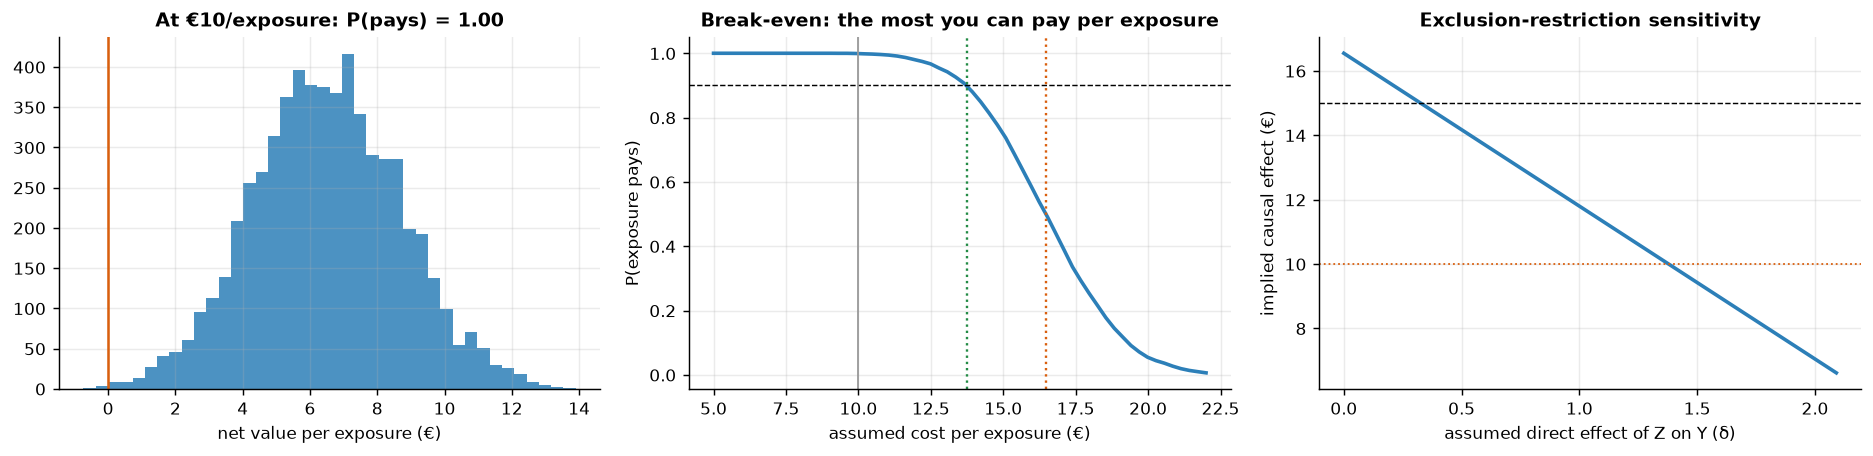

In [13]:
COST = 10.0
net = iv_post - COST; p_worth = (net > 0).mean()
# Break-even cost sweep: the decision rule is BUY when P(effect > c) > 0.9. Sweeping the
# per-exposure cost c turns the single (saturated) P(pays) into a curve and reads off the
# MAX viable cost-per-exposure — the budget cap the opening promised.
costs = np.linspace(5, 22, 60)
p_pays = np.array([(iv_post > c).mean() for c in costs])
c90 = np.quantile(iv_post, 0.10)     # highest cost still clearing P(effect>c) >= 0.90 — a POSTERIOR
                                     # quantile: a probability about beta, which no CI can give (§5x)
c50 = np.median(iv_post)             # coin-flip cost (P = 0.50)
# exclusion sensitivity: if Z has a direct effect delta on Y, corrected IV = (reduced - delta)/first
deltas = np.linspace(0, reduced*0.6, 20)
corrected = (reduced - deltas) / first

fig, ax = plt.subplots(1, 3, figsize=(14.5, 3.6))
ax[0].hist(net, bins=40, color=plots.BLUE, alpha=0.85); ax[0].axvline(0, color=plots.ORANGE, lw=1.4)
ax[0].set_xlabel("net value per exposure (€)"); ax[0].set_title(f"At €{COST:.0f}/exposure: P(pays) = {p_worth:.2f}")
ax[1].plot(costs, p_pays, color=plots.BLUE, lw=2)
ax[1].axhline(0.9, color="k", ls="--", lw=0.8); ax[1].axvline(c90, color=plots.GREEN, ls=":", lw=1.3)
ax[1].axvline(c50, color=plots.ORANGE, ls=":", lw=1.3); ax[1].axvline(COST, color=plots.GREY, lw=1)
ax[1].set_xlabel("assumed cost per exposure (€)"); ax[1].set_ylabel("P(exposure pays)")
ax[1].set_title("Break-even: the most you can pay per exposure")
ax[2].plot(deltas, corrected, color=plots.BLUE, lw=2); ax[2].axhline(true_effect, color="k", ls="--", lw=0.8)
ax[2].axhline(COST, color=plots.ORANGE, ls=":", lw=1); ax[2].set_xlabel("assumed direct effect of Z on Y (δ)")
ax[2].set_ylabel("implied causal effect (€)"); ax[2].set_title("Exclusion-restriction sensitivity")
fig.tight_layout()

break_delta = deltas[np.argmax(corrected < COST)] if np.any(corrected < COST) else np.nan
lo, hi = np.quantile(iv_post, 0.05), np.quantile(iv_post, 0.95)
print(f"At €{COST:.0f}/exposure: causal net €{net.mean():.1f}  ·  P(pays) {p_worth:.2f}\n  → "
      + ("BUY exposure (to the complier margin)" if p_worth > 0.9 else "hold"))
print(f"  P(pays)=1.00 is saturated, not assumed: the whole posterior\n"
      f"  [€{lo:.1f}, €{hi:.1f}] sits above €{COST:.0f}.")
print(f"Break-even sweep: exposure clears the 90%-probability bar up to €{c90:.1f}/exposure\n"
      f"  (the budget cap); at €{c50:.1f} it is a coin flip.\n"
      f"  So the €{COST:.0f} plan has ~€{c90-COST:.1f} of headroom per exposure before the call gets tight.")
print(f"Exclusion stress: the BUY call survives unless the instrument's direct effect\n"
      f"  exceeds δ≈{break_delta:.1f} (out of a €{reduced:.1f} reduced form) —\n"
      f"  trusting OLS (€{naive:.0f}) would overstate the value and overspend.")
print("  (the corrected line is a point-estimate bound — it re-solves the Wald ratio\n"
      "  at posterior means; carry the IV interval's width alongside it when briefing\n"
      "  the cap.)")

**Read-out.** Three numbers make the budget case, one per panel — and all three are read off **§5z's probit
posterior** (€16.5, 90% [€12.9, €20.1]), the corrected fit, not §4's Gaussian one. *Left*: at the current
€10/exposure the **causal** net value is ≈ **€6.5**/exposure with the entire posterior above zero — a
saturated BUY (P(pays) = 1.00), valid for the complier margin the instrument identifies. *Middle*: the sweep
turns the posterior into a procurement cap — the 90%-**probability** bar (a posterior quantity: the classical
arm of §5x has no such object to offer) holds up to ≈ **€13.7/exposure**, the coin-flip point is ≈ €16.5, so
the €10 plan has ~**€3.7** of genuine headroom. *Right*: the stress test bounds the untestable worry — the
BUY survives unless the lottery email itself drives more than δ ≈ €1.4 of sales directly, which against a
€3.5 total reduced form would be a large leak (a plain encouragement email with no product content makes
that implausible; an email that doubles as an ad does not — design the instrument accordingly). The
management contrast to land: budgeting on OLS's €24 would sanction paying up to €24 for something causally
worth ≈ €15 — a €9 gap against the simulator's answer key. On real data the truth is unknown, so the wedge
you'd actually avoid is OLS − IV ≈ **€7.2**/exposure (the IV prices the exposure at ≈ €16.5); either way,
times every exposure bought, that is the price of mistaking correlation for incrementality — the cell below
prices that same error at campaign scale (≈ **€7.2M** per quarter at 1M exposures). Note what the correct
likelihood did to the *decision*, not just to the estimate: a lower, more honest posterior tightens the cap
and eats into the headroom. A misspecified first stage does not merely mis-report a number — it authorizes a
higher bid.

### The one-paragraph decision

> **What I'd tell the CMO.** Buy the exposure at the current €10: the causal value per exposure (≈ €16.5,
> 90% [€12.9, €20.1] — the binary-aware IV posterior of §5z) sits comfortably clear of cost — P(pays) is
> saturated at 1.00 — and the break-even sweep caps procurement at ≈ **€13.7** per exposure at 90% posterior
> probability, coin-flip near €16.5, so the €10 plan carries roughly **€3.7** of headroom. **Scope:** that
> number is earned on the *complier margin* — the ≈ 21 pp of customers the encouragement actually tips into
> seeing the ad — and says nothing about always-exposed loyalists; that is the right scope for this call,
> because a budget buys *incremental* exposure. **Fragility, priced:** the BUY survives a direct-effect leak
> of the lottery into sales up to δ ≈ €1.4 of the €3.5 reduced form (a large leak for a content-free lottery
> email), and survives the remaining finite-sample bias of +€0.9 that §5z leaves on the table (§5b's Gaussian
> fit carried +€1.5 and under-covered; the probit halves it and covers at the nominal rate); it would *not*
> survive a weak instrument — which is why F ≈ 156 was checked before anything else (§5c shows the crash we
> avoided). **The mistake we didn't make:**
> budgeting on the naive €23.7 would sanction paying several euros of non-causal value on every
> exposure bought — the cell below prices that error at campaign scale, and the JSON carries every number
> a deck needs.

In [14]:
import json
VOLUME = 1_000_000   # exposures per quarter — a stated planning volume, scale to your buy
overpay = float(naive - iv_post.mean())
lo90, hi90 = float(np.quantile(iv_post, 0.05)), float(np.quantile(iv_post, 0.95))
print(f"Campaign-scale cost of the naive number: an OLS-calibrated cap sanctions\n"
      f"  ≈ €{overpay:.1f} of non-causal value per exposure; at {VOLUME:,} exposures/quarter that\n"
      f"  authorizes ≈ €{overpay * VOLUME / 1e6:.1f}M per quarter for value that does not exist\n"
      f"  (€{(naive - hi90) * VOLUME / 1e6:.1f}M–€{(naive - lo90) * VOLUME / 1e6:.1f}M against the IV 90% interval).")
decision = {
    "true_effect": float(TRUE), "ols": round(float(naive), 2), "wald": round(float(wald), 2),
    "iv_mean": round(float(iv_post.mean()), 2), "iv_ci90": [round(lo90, 2), round(hi90, 2)],
    "first_stage_F": round(float(Fstat), 1), "complier_share_pp": round(float((fs[1] - fs[0]) * 100), 1),
    # rho: the SHIPPED model is the probit, so export ITS rho. The Gaussian's is kept under a
    # separate key — mixing a probit effect with a Gaussian rho in one record is how a chapter
    # ends up describing two different models in one sentence.
    "rho_mean": round(float(rho_pr.mean()), 3),
    "rho_mean_gaussian": (round(float(_rho.mean()), 3) if _rho is not None else None),
    "cost_per_exposure": float(COST), "budget_cap_c90": round(float(c90), 2),
    "coinflip_c50": round(float(c50), 2),
    "exclusion_break_delta": round(float(break_delta), 2),
    "multiseed_bias": round(float(pr_means.mean() - TRUE), 2),
    "multiseed_coverage": f"{int(pr_covs.sum())}/{NSEED}",
    "multiseed_bias_gaussian": round(float(pts.mean() - TRUE), 2),
    "multiseed_coverage_gaussian": f"{cov}/{NSEED}",
    "iv_mean_gaussian": round(float(iv_post_gauss.mean()), 2),
    "naive_overpay_eur_per_quarter_at_1M": round(float(overpay * VOLUME)),
}
print(json.dumps(decision, indent=2))

Campaign-scale cost of the naive number: an OLS-calibrated cap sanctions
  ≈ €7.2 of non-causal value per exposure; at 1,000,000 exposures/quarter that
  authorizes ≈ €7.2M per quarter for value that does not exist
  (€3.6M–€10.8M against the IV 90% interval).
{
  "true_effect": 15.0,
  "ols": 23.67,
  "wald": 16.55,
  "iv_mean": 16.49,
  "iv_ci90": [
    12.88,
    20.09
  ],
  "first_stage_F": 156.2,
  "complier_share_pp": 21.1,
  "rho_mean": 0.341,
  "rho_mean_gaussian": 0.218,
  "cost_per_exposure": 10.0,
  "budget_cap_c90": 13.74,
  "coinflip_c50": 16.48,
  "exclusion_break_delta": 1.43,
  "multiseed_bias": 0.88,
  "multiseed_coverage": "18/20",
  "multiseed_bias_gaussian": 1.5,
  "multiseed_coverage_gaussian": "16/20",
  "iv_mean_gaussian": 17.73,
  "naive_overpay_eur_per_quarter_at_1M": 7185116
}


## 7 · Caveats

- **LATE, not ATE.** IV speaks only for **compliers** — customers the encouragement moves (the Step-3
  table shows who is silent). Always-exposed loyalists and never-exposed skeptics may respond differently;
  report the scope.
- **Weak instruments are dangerous.** A small first stage (low F) inflates both variance and bias — §5c
  demonstrated the crash: below F ≈ 10 the estimate's spread explodes and its median drifts back toward
  OLS. Check F first (on real data, the Montiel Olea–Pflueger *effective* F), and if it is small, walk
  away rather than report the ratio.
- **Exclusion is untestable.** We formalized it ($Y_i(z,x) = Y_i(x)$), stress-tested it in step 6, and
  priced the leak that would flip the call; defend it on design, not data.
- **Monotonicity (no defiers).** IV's LATE interpretation assumes no one is pushed *away* from exposure by
  encouragement — usually plausible, worth stating (it deleted the defier row in Step 3's derivation).
- **The joint Gaussian was misspecified — and §5z fixed it.** §4b showed CausalPy's exposure margin failing
  by construction (32% of replicated "exposures" outside $[0,1]$: a 0/1 variable modelled linearly), and §5b
  priced the damage — bias **+€1.5**, coverage **80%** on a nominal-90% interval. §5z rewrites the first stage
  as a **probit**: bias **+€0.9**, coverage **90%** — nominal — and that corrected posterior (€16.5) is the one
  §6 spends. **What remains** is a small finite-sample bias of **+€0.9** (≈ 6% of €15), which §5b's
  Wald-across-$n$ check shows is finite-sample rather than structural: the identification itself is unbiased
  and its spread shrinks like $1/\sqrt{n}$. If you use CausalPy's Gaussian fit anyway (it is the library
  default), read its exposure equation's point estimate and $\rho$, never its posterior width — and expect the
  budget cap it implies to sit too high.
- **Real data next.** Notebook **11b** replays this playbook on the Criteo uplift dataset — randomized
  assignment as the instrument for actual ad exposure — where F, the complier share, and the budget cap
  must be earned from the data rather than planted in it.

## Book export

In [15]:
# ---------------------------------------------------------------- Book export (cmp.report)
# Chapter 13 never retypes a number: every figure in its prose is emitted HERE, from this
# executed run, into book/build/results/nb11.json -> macros.tex (see src/cmp/report.py). A
# missing macro is a LaTeX compile error, never a silent hole. Figures are re-rendered in book
# style (vector PDF, no in-figure title — the caption does that work) and closed immediately,
# so this cell changes nothing the notebook shows above.
import matplotlib as mpl
from cmp import report as R

def V(k, v, **kw):
    return R.value(f"nb11.{k}", v, **kw)

# --- the world, and the planted truth -------------------------------------------------
V("n", int(len(df)), fmt=",d")
V("seed", int(SEED), fmt="d")
V("true", true_effect, unit="EUR", fmt=".0f")
V("fs_lo", 100 * float(fs[0]), fmt=".0f")
V("fs_hi", 100 * float(fs[1]), fmt=".0f")
V("fs_shift", 100 * float(fs[1] - fs[0]), fmt="+.0f")
V("f_stat", float(Fstat), fmt=".0f")

# --- Step 0 · the classical arm --------------------------------------------------------
V("ovb", float(ovb), unit="EUR", fmt="+.1f")
V("ols_predicted", 15 + float(ovb), unit="EUR", fmt=".1f")
V("naive", float(naive), unit="EUR", fmt=".1f")
V("naive_se", float(ols_naive.se), unit="EUR", fmt=".2f")
V("naive_lo", float(ols_naive.ci[0]), unit="EUR", fmt=".1f")
V("naive_hi", float(ols_naive.ci[1]), unit="EUR", fmt=".1f")
V("naive_err", float(naive - true_effect), unit="EUR", fmt="+.1f")
V("naive_half", float(ols_naive.ci[1] - ols_naive.ci[0]) / 2, unit="EUR", fmt=".1f")
V("first", float(first), fmt=".4f")
V("first_se", float(first_st.se), fmt=".4f")
V("reduced", float(reduced), unit="EUR", fmt=".2f")
V("reduced_se", float(red_form.se), unit="EUR", fmt=".3f")
V("wald", float(wald), unit="EUR", fmt=".2f")
V("iv_est", float(iv2.estimate), unit="EUR", fmt=".1f")
V("iv_lo", float(iv2.ci[0]), unit="EUR", fmt=".1f")
V("iv_hi", float(iv2.ci[1]), unit="EUR", fmt=".1f")
V("iv_se", float(iv2.se), unit="EUR", fmt=".2f")
V("iv_half", float(iv2.ci[1] - iv2.ci[0]) / 2, unit="EUR", fmt=".1f")
V("iv_width", float(iv2.ci[1] - iv2.ci[0]), unit="EUR", fmt=".1f")
V("iv_err", float(iv2.estimate - true_effect), unit="EUR", fmt="+.1f")
V("wedge", float(naive - iv2.estimate), unit="EUR", fmt=".1f")
V("se_hand", float(_se_naive2nd), unit="EUR", fmt=".2f")
V("se_correct", float(iv2.se), unit="EUR", fmt=".2f")
V("se_robust", float(se_hc1), unit="EUR", fmt=".2f")
V("se_hand_ratio", float(_se_naive2nd / iv2.se), fmt=".2f")
V("se_robust_ratio", float(se_hc1 / iv2.se), fmt=".2f")
V("f_leak", float(abs(naive - true_effect) / _F), unit="EUR", fmt=".2f")

# --- §4 · the Bayesian arm -------------------------------------------------------------
_conv = est.convergence_report(iv_idata)
V("bayes_mean", float(iv_post.mean()), unit="EUR", fmt=".1f")
V("bayes_lo", float(np.quantile(iv_post, 0.05)), unit="EUR", fmt=".1f")
V("bayes_hi", float(np.quantile(iv_post, 0.95)), unit="EUR", fmt=".1f")
V("bayes_half", float(np.quantile(iv_post, 0.95) - np.quantile(iv_post, 0.05)) / 2,
  unit="EUR", fmt=".1f")
V("bayes_width", float(np.quantile(iv_post, 0.95) - np.quantile(iv_post, 0.05)),
  unit="EUR", fmt=".1f")
V("bayes_err", float(iv_post.mean() - true_effect), unit="EUR", fmt="+.1f")
V("bayes_sd", float(iv_post.std()), unit="EUR", fmt=".2f")
V("n_draws", int(iv_post.size), fmt=",d")
V("rhat", float(_conv["max_rhat"]), fmt=".3f")
V("ess", float(_conv["min_ess_bulk"]), fmt=",.0f")
V("divergences", int(_conv["n_divergences"]), fmt="d")
V("rho", float(_rho.mean()), fmt="+.2f")
V("rho_lo", float(np.quantile(_rho, 0.05)), fmt="+.2f")
V("rho_hi", float(np.quantile(_rho, 0.95)), fmt="+.2f")
V("est_diff", float(abs(iv2.estimate - iv_post.mean())), unit="EUR", fmt=".1f")

# --- priors, priced (the CausalPy default, FITTED rather than asserted) ----------------
V("prior_def_mean", float(_post_def.mean()), unit="EUR", fmt=".1f")
V("prior_def_lo", float(_dlo), unit="EUR", fmt=".1f")
V("prior_def_hi", float(_dhi), unit="EUR", fmt=".1f")
V("prior_def_width", float(_dhi - _dlo), unit="EUR", fmt=".1f")
V("prior_weak_width", float(_whi - _wlo), unit="EUR", fmt=".1f")
V("prior_narrow_factor", float((_whi - _wlo) / (_dhi - _dlo)), fmt=".1f")

# --- §4b · the posterior predictive check ----------------------------------------------
V("ppc_out_pct", 100 * float(_out_share), fmt=".0f")
V("ppc_rep_sd", float(Yrep.std(axis=1).mean()), unit="EUR", fmt=".1f")
V("ppc_obs_sd", float(Yobs.std()), unit="EUR", fmt=".1f")

# --- §5b · recovery across fresh samples -----------------------------------------------
V("n_seeds", int(NSEED), fmt="d")
V("seed_mean", float(pts.mean()), unit="EUR", fmt=".1f")
V("seed_bias", float(pts.mean() - TRUE), unit="EUR", fmt="+.1f")
V("seed_bias_pct", 100 * float(pts.mean() - TRUE) / TRUE, fmt="+.0f")
V("seed_sd", float(pts.std()), unit="EUR", fmt=".1f")
V("seed_cov_n", int(cov), fmt="d")
V("seed_cov_pct", 100 * float(cov) / NSEED, fmt=".0f")

# The identification alone, across n: the closed-form Wald on fresh draws (no MCMC). Recomputed
# here exactly as §5b's cell computed it, so the table carries the numbers that cell printed.
_wald_rows, _wald_big_bias = [], None
for _n in [1000, 3000, 10000]:
    _w = []
    for _sd in range(_NS):
        _d, _ = dgp.iv_ad_exposure(n=_n, true_effect=TRUE, seed=500 + _sd)
        _Zr = np.column_stack([np.ones(_n), _d["encouragement"].values])
        _red = np.linalg.lstsq(_Zr, _d["sales"].values, rcond=None)[0][1]
        _fst = np.linalg.lstsq(_Zr, _d["ad_exposure"].values, rcond=None)[0][1]
        _w.append(_red / _fst)
    _w = np.array(_w)
    _wald_big_bias = float(_w.mean() - TRUE)
    _wald_rows.append({"Sample size n": f"{_n:,}", "Mean Wald (€)": f"{_w.mean():.1f}",
                       "Bias (€)": f"{_w.mean() - TRUE:+.1f}", "Spread, sd (€)": f"{_w.std():.2f}"})
V("wald_n_seeds", int(_NS), fmt="d")
V("wald_bias_big", _wald_big_bias, unit="EUR", fmt="+.1f")

# --- §5c · the weak-instrument sweep ---------------------------------------------------
_g_last, _F_last, _ws_last = sweep[-1]
_wklo, _wkhi = np.quantile(_ws_last, [0.05, 0.95])
V("weak_f_worst", float(_F_last), fmt=".1f")
V("weak_lo", float(_wklo), unit="EUR", fmt=".0f")
V("weak_hi", float(_wkhi), unit="EUR", fmt=".0f")
V("weak_median_worst", float(np.median(_ws_last)), unit="EUR", fmt=".1f")
V("weak_n_draws", int(NSW), fmt="d")
V("weak_gamma_top", float(GAMMAS[0]), fmt=".1f")

# --- §6 · the euro decision ------------------------------------------------------------
V("cost", float(COST), unit="EUR", fmt=".0f")
V("p_pays", float(p_worth), fmt=".2f")
V("net", float(net.mean()), unit="EUR", fmt=".1f")
V("cap", float(c90), unit="EUR", fmt=".1f")
V("coinflip", float(c50), unit="EUR", fmt=".1f")
V("headroom", float(c90 - COST), unit="EUR", fmt=".1f")
V("break_delta", float(break_delta), unit="EUR", fmt=".1f")
V("break_delta_pct", 100 * float(break_delta / reduced), fmt=".0f")
V("p_at_ten", float((iv_post > 10.0).mean()), fmt=".2f")
V("p_at_fifteen", float((iv_post > 15.0).mean()), fmt=".2f")
V("p_at_eighteen", float((iv_post > 18.0).mean()), fmt=".2f")
V("volume", int(VOLUME), fmt=",d")
V("overpay", float(overpay), unit="EUR", fmt=".1f")
V("overpay_m", float(overpay * VOLUME / 1e6), unit="EURm", fmt=".1f")
V("overpay_m_lo", float((naive - hi90) * VOLUME / 1e6), unit="EURm", fmt=".1f")
V("overpay_m_hi", float((naive - lo90) * VOLUME / 1e6), unit="EURm", fmt=".1f")

# --- tables (cells are plain text: report.table escapes them; only headers carry math) ---
R.table(pd.DataFrame([
    {"Regression": "(1) naive OLS, Y on X  [BIASED]", "Coefficient": f"{naive:.2f}",
     "SE": f"{ols_naive.se:.3f}",
     "90% CI": f"[{ols_naive.ci[0]:.2f}, {ols_naive.ci[1]:.2f}]", "Unit": "€ / exposure"},
    {"Regression": "(2) first stage, X on Z", "Coefficient": f"{first:.4f}",
     "SE": f"{first_st.se:.4f}",
     "90% CI": f"[{first_st.ci[0]:.4f}, {first_st.ci[1]:.4f}]", "Unit": "exposures / lottery"},
    {"Regression": "(3) reduced form, Y on Z", "Coefficient": f"{reduced:.3f}",
     "SE": f"{red_form.se:.3f}",
     "90% CI": f"[{red_form.ci[0]:.2f}, {red_form.ci[1]:.2f}]", "Unit": "€ / lottery"},
    {"Regression": "(4) ratio (3)/(2) = 2SLS: the LATE", "Coefficient": f"{iv2.estimate:.2f}",
     "SE": f"{iv2.se:.2f}",
     "90% CI": f"[{iv2.ci[0]:.2f}, {iv2.ci[1]:.2f}]", "Unit": "€ / exposure"},
]), "nb11.rungs", align="lrrcl",
    caption=(f"The whole of applied IV, in four rows and no likelihood (HC1 standard errors "
             f"throughout, $n = {len(df):,}$, planted truth \\texteuro{true_effect:.0f} per "
             f"exposure). Rows (2) and (3) each regress on the "
             f"\\emph{{randomized}} lottery, so each is a clean experiment; neither is the answer, "
             f"because one is denominated in exposures and the other in euros. Their ratio is the "
             f"answer, and it is exactly what two-stage least squares computes: the notebook asserts "
             f"$|\\hat\\delta/\\hat\\pi - \\hat\\beta_{{\\text{{2SLS}}}}| < 10^{{-8}}$ rather than "
             f"asking the reader to take it on faith. Row (1) is the number the business would "
             f"otherwise have used, and it is \\texteuro{naive - true_effect:+.1f} wrong."),
    label="tab:iv:rungs")

R.table(pd.DataFrame([
    {"Standard error of the same point estimate": "hand-rolled 2nd stage (residuals vs fitted X)",
     "SE (€)": f"{_se_naive2nd:.2f}", "Ratio": f"{_se_naive2nd / iv2.se:.2f}x",
     "Verdict": "WRONG — too wide"},
    {"Standard error of the same point estimate": "proper 2SLS (residuals vs the real X)",
     "SE (€)": f"{iv2.se:.2f}", "Ratio": "1.00x", "Verdict": "correct"},
    {"Standard error of the same point estimate": "2SLS with an HC1 sandwich",
     "SE (€)": f"{se_hc1:.2f}", "Ratio": f"{se_hc1 / iv2.se:.2f}x", "Verdict": "robustness check"},
]), "nb11.se", align="lrrl",
    caption=(f"Three formulas, one point estimate (\\texteuro{iv2.estimate:.1f} per exposure in every "
             f"row). Regressing $Y$ on the fitted $\\hat X$ recovers the 2SLS \\emph{{coefficient}} "
             f"exactly and its \\emph{{standard error}} not at all: it comes out "
             f"{_se_naive2nd / iv2.se:.2f}$\\times$ too large. Note the direction --- \\textbf{{too "
             f"wide, not too narrow}}, which is the opposite of the folklore. Heteroskedasticity, by "
             f"contrast, barely moves it ({se_hc1 / iv2.se:.2f}$\\times$): the homoskedastic 2SLS "
             f"interval is safe to report as it stands."),
    label="tab:iv:se")

R.table(pd.DataFrame(_wald_rows), "nb11.waldn", align="rrrr",
    caption=(f"The identification, isolated. The closed-form Wald ratio --- two least-squares slopes "
             f"and a division; no prior, no likelihood, no sampler --- on {_NS} fresh draws at each "
             f"sample size (planted truth \\texteuro{TRUE:.0f} per exposure). It stays pinned on the "
             f"truth while its spread shrinks like $1/\\sqrt{{n}}$. Whatever residual bias the "
             f"posterior mean shows in \\cref{{sec:iv:valid}} therefore belongs to the Bayesian "
             f"\\emph{{model}}, not to the IV logic."),
    label="tab:iv:waldn")

R.table(pd.DataFrame([
    {"First-stage strength (gamma)": f"{g:.2f}", "Median F": f"{medF:,.1f}",
     "Median Wald (€)": f"{np.median(ws):.1f}",
     "90% range across draws (€)":
         f"[{np.quantile(ws, 0.05):.1f}, {np.quantile(ws, 0.95):.1f}]"}
    for g, medF, ws in sweep
]), "nb11.weak", align="rrrc",
    caption=(f"The $F > 10$ rule, run backwards. The encouragement coefficient $\\gamma$ is turned "
             f"down from this chapter's {GAMMAS[0]} to nearly nothing and the closed-form Wald ratio "
             f"recomputed on {NSW} fresh datasets at each setting (the failure being demonstrated "
             f"belongs to the \\emph{{identification}}, so no sampler is involved). The median holds "
             f"up longer than the spread does: at $F \\approx {_F_last:.1f}$ a single draw's 90\\,\\% "
             f"range spans \\texteuro{_wklo:.0f} to \\texteuro{_wkhi:.0f} --- far wider than the "
             f"\\texteuro{naive - TRUE:.1f} of OLS bias the instrument was hired to remove --- while "
             f"the median drifts back toward OLS. A weak instrument is worse than none."),
    label="tab:iv:weak")

_blo, _bhi = np.quantile(iv_post, [0.05, 0.95])
R.table(pd.DataFrame([
    {"Estimator (€ per exposure)": "naive OLS · HC1  [BIASED]", "Est.": f"{naive:.1f}",
     "5%": f"{ols_naive.ci[0]:.1f}", "95%": f"{ols_naive.ci[1]:.1f}",
     "±half": f"{(ols_naive.ci[1] - ols_naive.ci[0]) / 2:.1f}",
     "|err|": f"{abs(naive - true_effect):.1f}", "P(beats €15)": "not defined"},
    {"Estimator (€ per exposure)": "Wald ratio = 2SLS · classical", "Est.": f"{iv2.estimate:.1f}",
     "5%": f"{iv2.ci[0]:.1f}", "95%": f"{iv2.ci[1]:.1f}",
     "±half": f"{(iv2.ci[1] - iv2.ci[0]) / 2:.1f}",
     "|err|": f"{abs(iv2.estimate - true_effect):.1f}", "P(beats €15)": "not defined"},
    {"Estimator (€ per exposure)": "Bayesian IV posterior", "Est.": f"{iv_post.mean():.1f}",
     "5%": f"{_blo:.1f}", "95%": f"{_bhi:.1f}", "±half": f"{(_bhi - _blo) / 2:.1f}",
     "|err|": f"{abs(iv_post.mean() - true_effect):.1f}",
     "P(beats €15)": f"{(iv_post > 15.0).mean():.2f}"},
]), "nb11.compare", align="lrrrrrc",
    caption=(f"The same estimand (the complier LATE), the same four assumptions, the same "
             f"{len(df):,} customers: only the apparatus differs (planted truth "
             f"\\texteuro{true_effect:.0f}). The first two rows carry 90\\,\\% \\emph{{confidence}} "
             f"intervals and the third a 90\\,\\% \\emph{{credible}} interval --- printed in the same "
             f"columns, they are not the same object, and only the third can populate the last one. "
             f"The classical arm is the closer of the two causal rows on this seed "
             f"(\\texteuro{abs(iv2.estimate - true_effect):.1f} against "
             f"\\texteuro{abs(iv_post.mean() - true_effect):.1f}), and the biased row carries the "
             f"tightest interval in the chapter."),
    label="tab:iv:compare")

# --- figures (book style: vector PDF, no in-figure title, closed so nothing renders inline) ---
with mpl.rc_context(R.book_style()):
    f = plt.figure(figsize=(6.6, 3.3)); a = f.add_subplot(111)
    _pos = {"encouragement\nZ": (0.05, 0.25), "exposure\nX": (0.5, 0.25),
            "sales\nY": (0.95, 0.25), "intent U\n(unobserved)": (0.725, 0.95)}
    _edges = [("encouragement\nZ", "exposure\nX"), ("exposure\nX", "sales\nY"),
              ("intent U\n(unobserved)", "exposure\nX"), ("intent U\n(unobserved)", "sales\nY")]
    plots.draw_dag(a, _pos, _edges, node_colors={"intent U\n(unobserved)": "#f6e3c5"}, title=None)
    a.text(0.27, 0.38, "relevance: the Z→X arrow\n(testable: the first-stage F)",
           ha="center", fontsize=8, color=plots.GREEN)
    a.text(0.50, -0.02, "exclusion: NO direct Z→Y arrow", ha="center", fontsize=8,
           color=plots.ORANGE)
    a.text(0.26, 0.86, "exogeneity: NO U→Z arrow", ha="center", fontsize=8, color=plots.ORANGE)
    f.tight_layout()
    R.figure(f, "nb11.dag", caption=(
        "Read the diagram by its absences. The unobserved intent $U$ forks into both exposure and "
        "sales --- that fork is the endogeneity, and no adjustment can remove a variable that was "
        "never recorded. The instrument $Z$ has exactly \\emph{one} outgoing arrow. Exclusion and "
        "exogeneity are not things $Z$ \\emph{does}: they are arrows $Z$ \\emph{does not have}, which "
        "is precisely why no dataset can test them and only a design can defend them. Relevance is "
        "the one arrow $Z$ must have, and the only one of the four assumptions the data can check."),
        label="fig:iv:dag")
    plt.close(f)

    f = plt.figure(figsize=(6.9, 3.0)); a2 = f.subplots(1, 2)
    a2[0].hist(iv_post, bins=40, color=plots.BLUE, alpha=0.85, label="Bayesian IV posterior")
    a2[0].axvline(true_effect, color="k", ls="--", lw=1.4, label=f"true €{true_effect:.0f}")
    a2[0].axvline(naive, color=plots.ORANGE, lw=1.6, label=f"OLS €{naive:.1f}")
    a2[0].axvline(wald, color=plots.GOLD, lw=1.2, ls=":", label=f"Wald / 2SLS €{wald:.1f}")
    a2[0].set_xlabel("exposure→sales effect (€)"); a2[0].set_ylabel("posterior draws")
    a2[0].legend(frameon=False, fontsize=8)
    a2[1].bar(["not encouraged", "encouraged"], [fs[0], fs[1]], color=[plots.GREY, plots.GREEN],
              alpha=0.9)
    a2[1].set_ylabel("P(exposed)")
    f.tight_layout()
    R.figure(f, "nb11.bias", caption=(
        f"\\emph{{Left}}: the self-selection, removed. Naive OLS (orange) prices an exposure at "
        f"\\texteuro{naive:.1f}, well above the planted \\texteuro{true_effect:.0f}, because it "
        f"credits the ad with the enthusiasm of the people who sought it out. The Wald ratio (gold) "
        f"and the posterior (blue) both fall back toward the truth, and the horizontal distance from "
        f"orange to blue --- \\texteuro{naive - iv_post.mean():.1f} per exposure --- \\emph{{is}} the "
        f"self-selection wedge: what a budget calibrated on the dashboard overpays on every exposure "
        f"bought. \\emph{{Right}}: the first stage. The lottery lifts the exposure rate from "
        f"{100 * fs[0]:.0f}\\,\\% to {100 * fs[1]:.0f}\\,\\%, and that "
        f"{100 * (fs[1] - fs[0]):.0f}-point shift is both the instrument's relevance "
        f"($F = {Fstat:.0f}$) and, under monotonicity, the complier share itself."),
        label="fig:iv:bias")
    plt.close(f)

    f = plt.figure(figsize=(6.9, 2.9)); a2 = f.subplots(1, 2)
    _by = np.linspace(Yobs.min(), Yobs.max(), 50)
    for _y in Yrep:
        _h, _ = np.histogram(_y, bins=_by, density=True)
        a2[0].plot(_by[:-1], _h, color=plots.BLUE, alpha=0.15, lw=0.8, drawstyle="steps-post")
    _h, _ = np.histogram(Yobs, bins=_by, density=True)
    a2[0].plot(_by[:-1], _h, color="k", lw=1.8, drawstyle="steps-post", label="observed sales")
    a2[0].plot([], [], color=plots.BLUE, alpha=0.6, label=f"{len(Yrep)} model replicates")
    a2[0].set_xlabel("sales (€)"); a2[0].set_ylabel("density")
    a2[0].legend(frameon=False, fontsize=8)
    _bx = np.linspace(-0.8, 1.8, 60)
    for _x in Xrep:
        _h, _ = np.histogram(_x, bins=_bx, density=True)
        a2[1].plot(_bx[:-1], _h, color=plots.BLUE, alpha=0.15, lw=0.8, drawstyle="steps-post")
    a2[1].bar([0, 1], [np.mean(Xobs == 0), np.mean(Xobs == 1)], width=0.07, color="k", alpha=0.85,
              label="observed exposure (0/1)")
    a2[1].axvspan(-0.8, 0, color=plots.ORANGE, alpha=0.12)
    a2[1].axvspan(1, 1.8, color=plots.ORANGE, alpha=0.12)
    a2[1].text(-0.4, a2[1].get_ylim()[1] * 0.9, "impossible", ha="center", fontsize=7,
               color=plots.ORANGE)
    a2[1].text(1.4, a2[1].get_ylim()[1] * 0.9, "impossible", ha="center", fontsize=7,
               color=plots.ORANGE)
    a2[1].set_xlabel("exposure"); a2[1].legend(frameon=False, fontsize=8)
    f.tight_layout()
    R.figure(f, "nb11.ppc", caption=(
        f"The posterior predictive check, and the margin it is designed to fail. \\emph{{Left}}: "
        f"replicate sales distributions from the fitted joint model track the observed one "
        f"(replicate sd \\texteuro{Yrep.std(axis=1).mean():.1f} against an observed "
        f"\\texteuro{Yobs.std():.1f}), which is what licenses reading $\\beta$ off the outcome "
        f"equation. \\emph{{Right}}: the same model's replicated \\emph{{exposures}} are smooth bell "
        f"curves, and {100 * _out_share:.0f}\\,\\% of their mass falls below 0 or above 1 --- "
        f"exposures no customer can have. That is the linear-probability first stage made visible "
        f"rather than footnoted. It is why \\cref{{sec:iv:valid}} finds a small upward bias in the "
        f"posterior mean, and why the exposure equation's point estimate and $\\rho$ may be read but "
        f"its posterior \\emph{{width}} may not."),
        label="fig:iv:ppc")
    plt.close(f)

    f = plt.figure(figsize=(6.6, 3.5)); a = f.add_subplot(111)
    _rj2 = np.random.default_rng(0)
    for g, medF, ws in sweep:
        _xj = medF * np.exp(_rj2.normal(0, 0.06, len(ws)))
        a.scatter(_xj, np.clip(ws, -40, 100), s=16, alpha=0.5, color=plots.BLUE)
        a.scatter([medF], [np.median(ws)], s=95, marker="D", color=plots.GOLD, zorder=4,
                  edgecolor="k", linewidth=0.6)
    a.set_xscale("log"); a.set_ylim(-42, 102)
    a.axhline(TRUE, color="k", ls="--", lw=1.2); a.axhline(naive, color=plots.ORANGE, lw=1.4)
    a.axvline(10, color=plots.GREY, ls=":", lw=1.6)
    _xmax = a.get_xlim()[1]
    a.text(_xmax, TRUE, f" true €{TRUE:.0f}", va="center", fontsize=8)
    a.text(_xmax, naive, f" OLS €{naive:.1f}", va="center", fontsize=8, color=plots.ORANGE)
    a.text(10, -36, " F = 10", fontsize=8, color="0.35")
    a.set_xlabel("first-stage F (median across draws, log scale)")
    a.set_ylabel("closed-form Wald estimate (€)")
    f.tight_layout()
    R.figure(f, "nb11.weakfig", caption=(
        f"What the first-stage F is \\emph{{for}}. Every column is the same estimator on the same "
        f"market; only the instrument's strength changes ({NSW} fresh draws per setting, medians in "
        f"gold). At the right edge --- this chapter's regime, $F$ in the hundreds --- the estimates "
        f"hug the planted truth. Moving left, the spread widens smoothly and then, below the dotted "
        f"$F = 10$ line, explodes: single draws land below zero or at several times the truth, and "
        f"the median drifts up toward the OLS line the instrument was hired to escape. This is the "
        f"$1/F$ approximation read right to left. With a nearly irrelevant instrument the Wald "
        f"denominator is sampling noise around zero, so the ratio inherits OLS's bias \\emph{{and}} "
        f"an enormous variance --- while still wearing the costume of a causal estimate."),
        label="fig:iv:weak")
    plt.close(f)

    f = plt.figure(figsize=(6.9, 2.5)); a3 = f.subplots(1, 3)
    a3[0].hist(net, bins=40, color=plots.BLUE, alpha=0.85)
    a3[0].axvline(0, color=plots.ORANGE, lw=1.4)
    a3[0].set_xlabel("net value / exposure (€)"); a3[0].set_ylabel("draws")
    a3[1].plot(costs, p_pays, color=plots.BLUE, lw=2)
    a3[1].axhline(0.9, color="k", ls="--", lw=0.8)
    a3[1].axvline(c90, color=plots.GREEN, ls=":", lw=1.3)
    a3[1].axvline(c50, color=plots.ORANGE, ls=":", lw=1.3)
    a3[1].axvline(COST, color=plots.GREY, lw=1)
    a3[1].set_xlabel("assumed cost / exposure (€)"); a3[1].set_ylabel("P(exposure pays)")
    a3[2].plot(deltas, corrected, color=plots.BLUE, lw=2)
    a3[2].axhline(true_effect, color="k", ls="--", lw=0.8)
    a3[2].axhline(COST, color=plots.ORANGE, ls=":", lw=1)
    a3[2].set_xlabel("assumed direct effect δ (€)")
    a3[2].set_ylabel("implied causal effect (€)")
    f.tight_layout()
    R.figure(f, "nb11.euro", caption=(
        f"The decision, in euros --- and the price of the untestable assumption. \\emph{{Left}}: the "
        f"posterior of net value per exposure at the planned \\texteuro{COST:.0f} cost. The whole "
        f"posterior sits above zero, so $\\Prob(\\text{{pays}}) = {p_worth:.2f}$ is saturated rather "
        f"than assumed. \\emph{{Middle}}: sweeping the cost simply walks the posterior's quantile "
        f"function, and the crossing of the 0.9 bar is the bid cap, \\texteuro{c90:.1f} per exposure, "
        f"against a coin-flip price of \\texteuro{c50:.1f}. \\emph{{Right}}: the exclusion "
        f"restriction, priced. Granting the lottery a direct effect $\\delta$ on sales and correcting "
        f"the reduced form accordingly, the buy call survives until $\\delta \\approx "
        f"\\texteuro{break_delta:.1f}$ --- {100 * break_delta / reduced:.0f}\\,\\% of the entire "
        f"\\texteuro{reduced:.1f} reduced form would have to bypass exposure to overturn it."),
        label="fig:iv:euro")
    plt.close(f)

print(f"book export: {len([k for k in R.load() if k.startswith('nb11.')])} keys emitted "
      f"to book/build/results/nb11.json")


book export: 99 keys emitted to book/build/results/nb11.json
